# *The Second Type of Uncertainty in Monte Carlo Tree Search*

[Artículo de referencia](https://arxiv.org/pdf/2005.09645)

Para este trabajo he elegido el tema de *Toma de Decisiones bajo Incertidumbre, MonteCarlo Tree Search*.







## Código

En esta parte del código implementamos lo siguiente:


*   Las clases que usaremos para generar un grafo dirigido.
*   Los distintos ejemplos que luego emplearemos para estudiar el rendimiento de los métodos tratados a continuación.
* Los métodos Monte Carlo Tree Search (MCTS) propuesto en el artículo. La versión tradicional y la versión modificada (MCTS_T), que implementa $\sigma_T$ como una nueva variable para medir la profundidad que falta por explorar de cada nodo.



In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import math
import random
import numpy as np
from numpy.random import seed as setseed
from ipywidgets import IntSlider, Output, VBox
import ipywidgets as widgets

##################################
######  CLASE NODO Y GRAFO #######
##################################

class Nodo:
    #Nodos dirigidos (Padres = de donde vienen // Hijos = posibles nodos sucesivos // Recompensa = valor de recompensa al llegar al nodo)
    def __init__(self, nombre, recompensa = 0):
        self.nombre = nombre
        self.recompensa = recompensa
        self.padre = None #(Si se quiere considerar multiples padres, añadir formato lista [] y modificar funcion añadir_padre)
        self.hijos = [] #que es mejor [] o set()?

    def añadir_padre(self, padre):
        self.padre = padre

    def añadir_hijos(self, hijo):
        self.hijos.append(hijo)

    def añadir_recompensa(self, valor):
        self.recompensa += valor

    def recompensa(self):
        return(self.recompensa)


class Grafo:
    def __init__(self):
        self.nodos = []

    def añadir_nodo(self, nombre):
        nodo = Nodo(nombre)
        self.nodos.append(nodo)

    def obtener_nodo(self, nombre):
        for nodo in self.nodos:
            if nodo.nombre == nombre:
                return nodo
        return None

    def obtener_nodo_inicial(self):
        for nodo in self.nodos:
            if nodo.padre == None:
                return nodo

    def aristas(self, nombre1, nombre2):  # Nodo1 -> Nodo2 por ser digrafo
        nodo1 = self.obtener_nodo(nombre1)
        nodo2 = self.obtener_nodo(nombre2)
        if nodo1 is None or nodo2 is None:
            raise ValueError(f"Uno de los nodos no existe: {nombre1}, {nombre2}")
        nodo1.añadir_hijos(nodo2)
        nodo2.añadir_padre(nodo1)

#################################
####  CLASE ARBOL BINARIO #######
#################################
#Fue el primer ejemplo que implemente. Se podria omitir y quedarse solo con árbol N-ario (este es una subclase de ese)
class ArbolBinario:
    def __init__(self, prof1, prof2, gamma = 0.5): #prof1 = profundidad nodo 1 // prof2 = profundidad nodo 2
        self.prof1 = prof1
        self.prof2 = prof2

        self.grafo_arbol_binario = Grafo() #Con este grafo trabajaremos
        self.grafo_representacion = nx.DiGraph() #Con este grafo lo representamos visualmente

        self.grafo_arbol_binario.añadir_nodo('0') #Nodo raiz
        self.grafo_representacion.add_node('0')

        anterior = '0'
        for i in range(1, self.prof1+1):
            nombre = f'L{i}'
            self.grafo_arbol_binario.añadir_nodo(nombre)
            self.grafo_representacion.add_node(nombre)

            self.grafo_arbol_binario.aristas(anterior, nombre)
            self.grafo_representacion.add_edge(anterior, nombre)

            anterior = nombre
        #Recompensa
        nodo_final_1 = self.grafo_arbol_binario.obtener_nodo(f'L{self.prof1}')
        #nodo_final_1.añadir_recompensa(2**(self.prof1-1) * self.prof1 / (2**(self.prof1-1) * self.prof1 + 2**(self.prof2-1) * self.prof2)) # Recompensa exponencial basada en la profunidad por la profunidad // Recomepensa nodo final entre 0,1
        nodo_final_1.añadir_recompensa(2**(self.prof1-1) * self.prof1 * gamma**(1-self.prof1) / (2**(self.prof1-1) * self.prof1 + 2**(self.prof2-1) * self.prof2)) # Recompensa exponencial basada en la profunidad por la profunidad // Recomepensa nodo raiz entre 0,1

        anterior = '0'
        for i in range(1, self.prof2+1):
            nombre = f'R{i}'
            self.grafo_arbol_binario.añadir_nodo(nombre)
            self.grafo_representacion.add_node(nombre)

            self.grafo_arbol_binario.aristas(anterior, nombre)
            self.grafo_representacion.add_edge(anterior, nombre)

            anterior = nombre
        #Recompensa
        nodo_final_2 = self.grafo_arbol_binario.obtener_nodo(f'R{self.prof2}')
        #nodo_final_2.añadir_recompensa(2**(self.prof2-1)* self.prof2/ (2**(self.prof1-1) * self.prof1 + 2**(self.prof2-1) * self.prof2)) # Recompensa exponencial basada en la profunidad por la profunidad // Recomepensa nodo final entre 0,1
        nodo_final_2.añadir_recompensa(2**(self.prof2-1) * self.prof2 * gamma**(1-self.prof2)/ (2**(self.prof1-1) * self.prof1 + 2**(self.prof2-1) * self.prof2)) # Recompensa exponencial basada en la profunidad por la profunidad // Recomepensa nodo raiz entre 0,1

    def obtener_grafo(self):
        return self.grafo_arbol_binario

    def mostrar_grafo(self):
        setseed(2025)
        node_colors = []
        for nodo in self.grafo_representacion.nodes():
            if nodo == '0': # Nodo inicial verde
                node_colors.append('green')
            elif nodo == f'L{self.prof1}': # Nodo terminal Lprof1 rojo
                node_colors.append('red')
            elif nodo == f'R{self.prof2}': # Nodo terminal Rprof2 azul
                node_colors.append('blue')
            else: # Otros nodos en naranja
                node_colors.append('orange')

        plt.figure(figsize=(10, 8))
        try:
            pos = nx.nx_agraph.graphviz_layout(self.grafo_representacion, prog="dot")
        except:
            pos = nx.spring_layout(self.grafo_representacion)  # fallback si no está graphviz

        nx.draw(self.grafo_representacion, pos, with_labels=True, node_color=node_colors, node_size=1500, font_size=12, font_weight='bold', arrows=True)
        plt.title("Representación del Árbol Binario")
        plt.show()

#################################
####  CLASE ARBOL N-NARIO #######
#################################
class ArbolNario:
    def __init__(self, profundidades, gamma=0.5):
        """
        profundidades: lista de profundidades [prof1, prof2, ..., profN]
        gamma: factor de descuento
        """
        self.profundidades = profundidades
        self.num_ramas = len(profundidades)
        self.gamma = gamma

        self.grafo_arbol_nario = Grafo()
        self.grafo_representacion = nx.DiGraph()

        self.grafo_arbol_nario.añadir_nodo('0')
        self.grafo_representacion.add_node('0')

        # Guardar NOMBRES de nodos finales, no objetos
        self.nodos_finales_nombres = {}  # CAMBIO: almacenar nombres en lugar de objetos
        self.nodos_finales = {}  # Mantener para compatibilidad con obtener_nodo_final()

        for rama_idx, profundidad in enumerate(profundidades):
            letra_rama = chr(ord('A') + rama_idx)

            anterior = '0'
            for nivel in range(1, profundidad + 1):
                nombre = f'{letra_rama}{nivel}'
                self.grafo_arbol_nario.añadir_nodo(nombre)
                self.grafo_representacion.add_node(nombre)

                self.grafo_arbol_nario.aristas(anterior, nombre)
                self.grafo_representacion.add_edge(anterior, nombre)

                anterior = nombre

            # Guardar el NOMBRE del nodo final
            nombre_final = f'{letra_rama}{profundidad}'
            nodo_final = self.grafo_arbol_nario.obtener_nodo(nombre_final)
            self.nodos_finales_nombres[letra_rama] = nombre_final  # NUEVO: guardar nombre
            self.nodos_finales[letra_rama] = nodo_final  # Mantener para compatibilidad

            # Calcular recompensa normalizada
            numerador = 2**(profundidad - 1) * profundidad * (self.gamma**(1 - profundidad))
            denominador = sum(
                2**(self.profundidades[i] - 1) * self.profundidades[i]
                for i in range(self.num_ramas)
            )

            recompensa = numerador / denominador
            nodo_final.añadir_recompensa(recompensa)

    def obtener_grafo(self):
        return self.grafo_arbol_nario

    def obtener_nodo_final(self, rama):
        """Obtener el nodo final de una rama específica"""
        return self.nodos_finales.get(rama)

    def mostrar_grafo(self):
        setseed(2025)
        node_colors = []

        for nodo in self.grafo_representacion.nodes():
            if nodo == '0':  # Nodo inicial verde
                node_colors.append('green')
            elif nodo in self.nodos_finales_nombres.values():  # Nodos terminales rojos
                node_colors.append('red')
            else:  # Otros nodos en naranja claro
                node_colors.append('orange')

        plt.figure(figsize=(12, 8))
        try:
            pos = nx.nx_agraph.graphviz_layout(self.grafo_representacion, prog="dot")
        except:
            pos = nx.spring_layout(self.grafo_representacion)  # fallback

        nx.draw(self.grafo_representacion, pos, with_labels=True, node_color=node_colors,
                node_size=1500, font_size=12, font_weight='bold', arrows=True)
        plt.title("Representación del Árbol N-ario")
        plt.show()

############################################
####  CLASE ARBOL N-ARIO CON Hijos  #######
############################################

class ArbolNarioHijos:
    def __init__(self, profundidades, gamma=0.5):
        """
        profundidades: lista de profundidades [prof1, prof2, ..., profN]
        gamma: factor de descuento
        """
        self.profundidades = profundidades
        self.num_ramas = len(profundidades)
        self.gamma = gamma

        self.grafo_arbol_nario = Grafo()
        self.grafo_representacion = nx.DiGraph()

        self.grafo_arbol_nario.añadir_nodo('0')
        self.grafo_representacion.add_node('0')

        # Guardar NOMBRES de nodos finales
        self.nodos_finales_nombres = {}  # Nuevo: almacenar nombres de nodos con recompensa máxima
        self.nodos_finales = {}  # Mantener para compatibilidad
        self.nodos_hoja_terminal_nombres = {}  # Nuevo: almacenar nombres de todos los nodos hoja

        for rama_idx, profundidad in enumerate(profundidades):
            letra_rama = chr(ord('A') + rama_idx)

            anterior = '0'
            # Crear cadena de nodos para esta rama
            for nivel in range(1, profundidad + 1):
                nombre = f'{letra_rama}{nivel}'
                self.grafo_arbol_nario.añadir_nodo(nombre)
                self.grafo_representacion.add_node(nombre)

                self.grafo_arbol_nario.aristas(anterior, nombre)
                self.grafo_representacion.add_edge(anterior, nombre)

                anterior = nombre

            # Nodo final de la cadena principal
            nodo_final_cadena = self.grafo_arbol_nario.obtener_nodo(f'{letra_rama}{profundidad}')

            # Calcular recompensa normalizada
            numerador = 2**(profundidad - 1) * profundidad * (self.gamma**(1 - profundidad))
            denominador = sum(
                2**(self.profundidades[i] - 1) * self.profundidades[i]
                for i in range(self.num_ramas)
            )

            recompensa_maxima = numerador / denominador

            # Crear nodos hijos terminales
            # Solo uno tendrá la recompensa máxima, los demás tendrán 0
            for hijo_idx in range(1, profundidad + 1):
                nombre_hijo = f'{letra_rama}{profundidad}_{hijo_idx}'
                self.grafo_arbol_nario.añadir_nodo(nombre_hijo)
                self.grafo_representacion.add_node(nombre_hijo)

                self.grafo_arbol_nario.aristas(f'{letra_rama}{profundidad}', nombre_hijo)
                self.grafo_representacion.add_edge(f'{letra_rama}{profundidad}', nombre_hijo)

                # Solo el último hijo tiene la recompensa máxima
                if hijo_idx == profundidad:
                    nodo_hijo = self.grafo_arbol_nario.obtener_nodo(nombre_hijo)
                    nodo_hijo.añadir_recompensa(recompensa_maxima)
                    self.nodos_finales[letra_rama] = nodo_hijo
                    self.nodos_finales_nombres[letra_rama] = nombre_hijo  # NUEVO: guardar nombre

                # Guardar referencia a todos los nodos hoja por nombre
                self.nodos_hoja_terminal_nombres[nombre_hijo] = nombre_hijo  # NUEVO: guardar nombre

    def obtener_grafo(self):
        return self.grafo_arbol_nario

    def obtener_nodo_final(self, rama):
        """Obtener el nodo final de una rama específica (el que tiene recompensa máxima)"""
        return self.nodos_finales.get(rama)

    def mostrar_grafo(self):
        setseed(2025)

        node_colors = []

        for nodo in self.grafo_representacion.nodes():
            if nodo == '0':  # Nodo inicial verde
                node_colors.append('green')
            elif nodo in self.nodos_finales_nombres.values():  # Nodo terminal con recompensa máxima
                node_colors.append('red')
            elif nodo in self.nodos_hoja_terminal_nombres.values():  # Otros nodos terminales pero con recompensa nula
                node_colors.append('lightCoral')  # Color claro para nodos hoja sin recompensa
            else:  # Nodos intermedios
                node_colors.append('orange')

        plt.figure(figsize=(14, 10))
        try:
            pos = nx.nx_agraph.graphviz_layout(self.grafo_representacion, prog="dot")
        except:
            pos = nx.spring_layout(self.grafo_representacion)  # fallback

        nx.draw(self.grafo_representacion, pos, with_labels=True, node_color=node_colors,
                node_size=1500, font_size=10, font_weight='bold', arrows=True)
        plt.title("Representación del Árbol N-ario con Nodos Hoja Múltiples")
        plt.show()



#########################
######  CLASE MCTS ######
#########################

#IDEA: inicializar clase grafo binario, obtener el grafo y porporcionarselo a MCTS para resolverlo

class MCTS:
    def __init__(self, grafo):
        self.grafo = grafo
        self.node_inicial = grafo.obtener_nodo_inicial()
        self.nodos_conocidos = [self.node_inicial]
        self.visitas_nodos = {}
        self.recompensas_acumuladas_nodos = {}
        self.historial_rutas = []

    def inicializar_nodo(self, nombre_nodo):
        if nombre_nodo not in self.visitas_nodos:
            self.visitas_nodos[nombre_nodo] = 0
            self.recompensas_acumuladas_nodos[nombre_nodo] = 0.0

    def actualizar_visitas(self, nombre_nodo):
        self.inicializar_nodo(nombre_nodo)
        self.visitas_nodos[nombre_nodo] += 1

    def actualizar_recompensa_acumulada(self, nombre_nodo, recompensa):
        self.inicializar_nodo(nombre_nodo)
        self.recompensas_acumuladas_nodos[nombre_nodo] += recompensa

    def calcular_ucb(self, nombre_nodo, nombre_nodo_padre, c=1.4):
        self.inicializar_nodo(nombre_nodo)
        if self.visitas_nodos[nombre_nodo] == 0:
            ucb = float('inf')
        else:
            visitas_padre = self.visitas_nodos[nombre_nodo_padre]
            media = self.recompensas_acumuladas_nodos[nombre_nodo] / self.visitas_nodos[nombre_nodo]
            ucb = media + c * ( math.sqrt(visitas_padre) / self.visitas_nodos[nombre_nodo])  # Alternativas: ucb = media + c * ( (2 * math.log(visitas_padre) / self.visitas_nodos[nombre_nodo]) ** 0.5 )
        return ucb

    def mostrar_estadisticas(self):
        print("Estadísticas de los nodos:")
        for nombre_nodo in self.visitas_nodos:
            visitas = self.visitas_nodos[nombre_nodo]
            recompensa = self.recompensas_acumuladas_nodos[nombre_nodo]
            print(f"Nodo: {nombre_nodo}, Visitas: {visitas}, Recompensa acumulada: {recompensa}")

    def recompensa_acumulada(self):
        acumulador = 0
        for nombre_nodo in self.recompensas_acumuladas_nodos:
            acumulador += self.recompensas_acumuladas_nodos[nombre_nodo]
        return acumulador

    def guardar_rutas(self,ruta):
        self.historial_rutas.append(ruta)

    def representar_rutas(self):
        acum = 0

        for ruta in self.historial_rutas:
            G = nx.DiGraph()
            for i in range(len(ruta)): #Añadir nodos
                G.add_node(ruta[i])

            for i in range(len(ruta)-1): #Añadir aristas
                G.add_edge(ruta[i], ruta[i+1])

            nodos_colores = []
            for nodo in G.nodes():
                if nodo == '0': # Nodo inicial verde
                    nodos_colores.append('green')
                elif nodo == ruta[-1]: # Nodo terminal rojo
                    nodos_colores.append('red')
                else: # Otros nodos en naranja
                    nodos_colores.append('orange')
            plt.figure(figsize=(10, 8))
            try:
                pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
            except:
                pos = nx.spring_layout(G)  # fallback si no está graphviz
            nx.draw(G, pos, with_labels=True, node_color=nodos_colores, node_size=1500, font_size=12, font_weight='bold', arrows=True)
            plt.title("Representación MCTS iteracion: "+str(acum))
            plt.show()
            print(G.nodes())
            acum += 1

    def representar_rutas_slideshow(self):
        output = Output()
        slider = IntSlider(
            min=0,
            max=len(self.historial_rutas) - 1,
            step=1,
            description='Iteración:'
        )

        def actualizar_visualizacion(frame_num):
            output.clear_output(wait=True)

            with output:
                ruta = self.historial_rutas[frame_num]

                # Crear grafo
                G = nx.DiGraph()
                for nodo in ruta:
                    G.add_node(nodo)

                for i in range(len(ruta) - 1):
                    G.add_edge(ruta[i], ruta[i+1])

                # Asignar colores
                nodos_colores = []
                for nodo in G.nodes():
                    if nodo == '0':
                        nodos_colores.append('green')
                    elif nodo == ruta[-1]:
                        nodos_colores.append('red')
                    else:
                        nodos_colores.append('orange')

                # Layout
                try:
                    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
                except:
                    pos = nx.spring_layout(G, seed=42)

                # Dibujar
                plt.figure(figsize=(10, 8))
                nx.draw(G, pos, with_labels=True, node_color=nodos_colores,
                        node_size=1500, font_size=12, font_weight='bold', arrows=True)

                plt.title(f"Representación MCTS iteración: {frame_num}")
                plt.show()

        slider.observe(lambda change: actualizar_visualizacion(change['new']), names='value')

        return VBox([slider, output])

    def ejecutar_mcts(self, iteraciones, profundidad = 1, gamma = 0.5):
        for _ in range(iteraciones):
            nodo_actual = self.node_inicial
            self.actualizar_visitas(nodo_actual.nombre)

            ruta = [nodo_actual.nombre]

            # [1] Fase de selección
            se_segue = True
            while se_segue:
                hijos = nodo_actual.hijos
                if not hijos: # Nodo hoja alcanzado
                    break
                else:
                    for hijo in hijos:
                        self.inicializar_nodo(hijo.nombre)
                if any(self.visitas_nodos[hijo.nombre] == 0 for hijo in hijos): #Algún hijo sin explorar
                    # Seleccionar un hijo no visitado al azar
                    hijo_no_visitado = next(hijo for hijo in hijos if self.visitas_nodos[hijo.nombre] == 0)

                    nodo_actual = hijo_no_visitado
                    self.actualizar_visitas(nodo_actual.nombre)

                    ruta.append(nodo_actual.nombre)
                    se_segue = False # Salir del bucle de selección
                else: #Todos los hijos explorados
                    # Calcular UCB para cada hijo y seleccionar el mejor
                    ucb_values = [self.calcular_ucb(hijo.nombre,nodo_actual.nombre) for hijo in hijos]
                    max_ucb = max(ucb_values)
                    mejor_hijo = hijos[ucb_values.index(max_ucb)]

                    nodo_actual = mejor_hijo
                    self.actualizar_visitas(nodo_actual.nombre)

                    ruta.append(nodo_actual.nombre)

            # [2] Fase de simulación
            hijos = nodo_actual.hijos

            # [3] Fase de estimación recompensa
            recompensa_futura = 0
            for _ in range(profundidad):
                if not hijos:
                    break
                nodo_actual = hijos[random.randint(0,len(hijos)-1)]  # Elegir un hijo aleatoriamente
                #ruta.append(nodo_actual.nombre) # EN EL ROLLOUT NO SE AÑADE PARA ACTUALIZAR LOS NODOS VISITADOS ALEATOREAMENTE
                hijos = nodo_actual.hijos
                recompensa_futura += nodo_actual.recompensa

            # [4] Fase de retropropagación
            self.guardar_rutas(ruta)

            ruta_para_actualizar = ruta.copy()
            ruta_para_actualizar.remove(ruta_para_actualizar[0]) # Eliminar el nodo inicial para no actualizar su recompensa

            valor_acumulado = recompensa_futura
            for nombre_nodo in reversed(ruta):
                # Sumar la recompensa inmediata del nodo (si la hay) más el valor futuro descontado
                recompensa_inmediata = self.grafo.obtener_nodo(nombre_nodo).recompensa
                valor_acumulado = recompensa_inmediata + gamma * valor_acumulado
                self.actualizar_recompensa_acumulada(nombre_nodo, valor_acumulado)

##############################################################
######  CLASE MCTS_T (CON INCERTIDUMBRE EN PROFUNIDAD)  ######
##############################################################

#IMPORTANTE:
# 1) Vamos a suponer que la propagacion de sigma se hace siempre al finalizar la seleccion, que una vez que selecciono el nodo compruebo si era terminal y asigno valor nulo pero no antes. Propagacion de porfunidad en paso 4
class MCTS_T:
    def __init__(self, grafo):
        self.grafo = grafo
        self.node_inicial = grafo.obtener_nodo_inicial()
        self.nodos_conocidos = [self.node_inicial]
        self.visitas_nodos = {}
        self.profundidad_nodos = {} # Nueva variable para almacenar estimacion de la profundidad de cada nodo
        self.recompensas_acumuladas_nodos = {}
        self.historial_rutas = []

    def inicializar_nodo(self, nombre_nodo):
        if nombre_nodo not in self.visitas_nodos:
            self.visitas_nodos[nombre_nodo] = 0
            self.recompensas_acumuladas_nodos[nombre_nodo] = 0.0
            self.profundidad_nodos[nombre_nodo] = 1 # Cualquier nodo que no se juegue, a priori profundidad máxima (tiene sentido, maximo factor de exploracion debido a maxima incertidumbre)

    def actualizar_visitas(self, nombre_nodo):
        self.inicializar_nodo(nombre_nodo)  # Se puede omitir si ya se ha inicializado?
        self.visitas_nodos[nombre_nodo] += 1

    def actualizar_recompensa_acumulada(self, nombre_nodo, recompensa):
        self.inicializar_nodo(nombre_nodo) # Se puede omitir si ya se ha inicializado?
        self.recompensas_acumuladas_nodos[nombre_nodo] += recompensa

    def calcular_ucb(self, nombre_nodo, nombre_nodo_padre, c=1.4, lambda_sigma=0.5):

        self.inicializar_nodo(nombre_nodo)

        if self.visitas_nodos[nombre_nodo] == 0:
            return float('inf')

        visitas_padre = self.visitas_nodos[nombre_nodo_padre]
        media = self.recompensas_acumuladas_nodos[nombre_nodo] / self.visitas_nodos[nombre_nodo]

        # Factor de profundidad (σ_t)
        ###################################################
        # Solo se actualiza despues de selccionarlo, en la fase 4 de retropropagacion
        ###################################################
        sigma_T = self.profundidad_nodos[nombre_nodo]

        # UCB con factor de profundidad
        exploracion =  c * sigma_T *( math.sqrt(visitas_padre) / self.visitas_nodos[nombre_nodo])

        ucb = media + exploracion
        return ucb

    def mostrar_estadisticas(self):
        print("Estadísticas de los nodos:")
        for nombre_nodo in self.visitas_nodos:
            visitas = self.visitas_nodos[nombre_nodo]
            recompensa = self.recompensas_acumuladas_nodos[nombre_nodo]
            print(f"Nodo: {nombre_nodo}, Visitas: {visitas}, Recompensa acumulada: {recompensa}")

    def recompensa_acumulada(self):
        acumulador = 0
        for nombre_nodo in self.recompensas_acumuladas_nodos:
            acumulador += self.recompensas_acumuladas_nodos[nombre_nodo]
        return acumulador

    def guardar_rutas(self,ruta):
        self.historial_rutas.append(ruta)

    def representar_rutas(self):
        acum = 0

        for ruta in self.historial_rutas:
            G = nx.DiGraph()
            for i in range(len(ruta)): #Añadir nodos
                G.add_node(ruta[i])

            for i in range(len(ruta)-1): #Añadir aristas
                G.add_edge(ruta[i], ruta[i+1])

            nodos_colores = []
            for nodo in G.nodes():
                if nodo == '0': # Nodo inicial verde
                    nodos_colores.append('green')
                elif nodo == ruta[-1]: # Nodo terminal rojo
                    nodos_colores.append('red')
                else: # Otros nodos en naranja
                    nodos_colores.append('orange')
            plt.figure(figsize=(10, 8))
            try:
                pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
            except:
                pos = nx.spring_layout(G)  # fallback si no está graphviz
            nx.draw(G, pos, with_labels=True, node_color=nodos_colores, node_size=1500, font_size=12, font_weight='bold', arrows=True)
            plt.title("Representación MCTS iteracion: "+str(acum))
            plt.show()
            print(G.nodes())
            acum += 1
    def representar_rutas_slideshow(self):
        output = Output()
        slider = IntSlider(
            min=0,
            max=len(self.historial_rutas) - 1,
            step=1,
            description='Iteración:'
        )

        def actualizar_visualizacion(frame_num):
            output.clear_output(wait=True)

            with output:
                ruta = self.historial_rutas[frame_num]

                # Crear grafo
                G = nx.DiGraph()
                for nodo in ruta:
                    G.add_node(nodo)

                for i in range(len(ruta) - 1):
                    G.add_edge(ruta[i], ruta[i+1])

                # Asignar colores
                nodos_colores = []
                for nodo in G.nodes():
                    if nodo == '0':
                        nodos_colores.append('green')
                    elif nodo == ruta[-1]:
                        nodos_colores.append('red')
                    else:
                        nodos_colores.append('orange')

                # Layout
                try:
                    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
                except:
                    pos = nx.spring_layout(G, seed=42)

                # Dibujar
                plt.figure(figsize=(10, 8))
                nx.draw(G, pos, with_labels=True, node_color=nodos_colores,
                        node_size=1500, font_size=12, font_weight='bold', arrows=True)

                plt.title(f"Representación MCTS_T iteración: {frame_num}")
                plt.show()

        slider.observe(lambda change: actualizar_visualizacion(change['new']), names='value')

        return VBox([slider, output])

    def ejecutar_mcts(self, iteraciones, profundidad = 1, gamma = 0.5):
        for _ in range(iteraciones):
            nodo_actual = self.node_inicial
            self.actualizar_visitas(nodo_actual.nombre)

            ruta = [nodo_actual.nombre]

            # [1] Fase de selección
            se_segue = True
            while se_segue:
                hijos = nodo_actual.hijos
                if not hijos: # Nodo hoja alcanzado
                    break
                else:
                    for hijo in hijos:
                        self.inicializar_nodo(hijo.nombre)
                if any(self.visitas_nodos[hijo.nombre] == 0 for hijo in hijos):
                    # Seleccionar un hijo no visitado al azar
                    hijo_no_visitado = next(hijo for hijo in hijos if self.visitas_nodos[hijo.nombre] == 0)

                    nodo_actual = hijo_no_visitado
                    self.actualizar_visitas(nodo_actual.nombre)

                    ruta.append(nodo_actual.nombre)
                    se_segue = False # Salir del bucle de selección
                else:
                    # Calcular UCB para cada hijo y seleccionar el mejor
                    ucb_values = [self.calcular_ucb(hijo.nombre,nodo_actual.nombre) for hijo in hijos]
                    max_ucb = max(ucb_values)
                    mejor_hijo = hijos[ucb_values.index(max_ucb)]

                    nodo_actual = mejor_hijo
                    self.actualizar_visitas(nodo_actual.nombre)

                    ruta.append(nodo_actual.nombre)

            # [2] Fase de simulación
            hijos = nodo_actual.hijos

            # [3] Fase de estimación recompensa
            recompensa_futura = 0
            for _ in range(profundidad):
                if not hijos:
                    break
                nodo_actual = hijos[random.randint(0,len(hijos)-1)]  # Elegir un hijo aleatoriamente
                # Para la fase del rollout, no añadimos al historial de ruta los nodos jugados aleatoriamente
                hijos = nodo_actual.hijos
                recompensa_futura += nodo_actual.recompensa

            # [4] Fase de retropropagación
            self.guardar_rutas(ruta)

            ruta_para_actualizar = ruta.copy()
            ruta_para_actualizar.remove(ruta_para_actualizar[0]) # Eliminar el nodo inicial para no actualizar su recompensa

            valor_acumulado = recompensa_futura
            for nombre_nodo in reversed(ruta):
                # Sumar la recompensa inmediata del nodo (si la hay) más el valor futuro descontado
                recompensa_inmediata = self.grafo.obtener_nodo(nombre_nodo).recompensa
                valor_acumulado = recompensa_inmediata + gamma * valor_acumulado
                self.actualizar_recompensa_acumulada(nombre_nodo, valor_acumulado)

            # Actualizar factor de profundidad sigma_t para los nodos en la ruta
            for nombre_nodo in reversed(ruta):
                nodo = self.grafo.obtener_nodo(nombre_nodo)
                hijos = nodo.hijos
                if not hijos: # Si es terminal, incertidumbre = 0
                    self.profundidad_nodos[nombre_nodo] = 0.0
                    continue
                else:
                    numerador = 0
                    denominador = 0
                    for hijo in hijos:
                        self.inicializar_nodo(hijo.nombre) # Asegurar que el hijo está inicializado
                        if self.visitas_nodos[hijo.nombre] > 0:
                            numerador += self.profundidad_nodos[hijo.nombre] * self.visitas_nodos[hijo.nombre]
                            denominador += self.visitas_nodos[hijo.nombre]
                        else:
                            numerador += 1  # Máxima incertidumbre para hijos no visitados
                            denominador += 1
                    self.profundidad_nodos[nombre_nodo] = numerador / denominador
                    continue




## Introducción


El método MCTS propuesto en el artículo viene dado de la siguiente manera:



1.   **Fase de selección:** Descendemos por el árbol conocido de manera que:

$$ \pi_{tree}(h) = \text{argmax}_{a\in \mathcal{A}}\left[Q(h,a) + c · \frac{\sqrt{n(h)}}{n(h,a)}\right]$$

Siendo $h$ el historial/secuencia de selecciones de nodos hasta el instante actual, $a\in \mathcal{A}$ los distintos nodos posibles para ser seleccionados, $n(h)$ las veces que se ha seleccionado el nodo actual, $n(h,a)$ las veces que se ha seleccionado el nodo $a$, $c$ una constante para regular el valor optimista de exploración (en el código la hemos fijado $c = 1.4$), $Q(h,a) = \frac{W(h,a)}{n(h,a)}$ la recompensa media obtenida.

2.   **Fase de expansión:** Una vez encontrado un nodo sin explorar, es decir $n(h,a)=0$, pasamos a la fase 3. En caso de recorrer un camino completamente explorado y llegar a un nodo terminal, pasamos a la fase 4.

3. **Fase de despliegue:** Dada una profundidad definida $D$, a partir del nodo sin explorar $a$ recorremos una ruta de profundidad máxima $D$, o hasta alcanzar un nodo terminal mediante criterio de selección aleatorio. La suma de las recompensas obtenidas durante esta ruta aleatoria por el factor $\gamma$ (en el código la hemos fijado en $\gamma=0.5$ ) más el valor de la recompensa del nodo $a$ será el valor del nodo, denotado por $R(a) = R_a + \gamma \sum_{i=1}^DR_{a_i}$.

4. **Fase de propagación:** Recursivamente vamos propagando el valor de las recompensas obtenidas para la ruta de profundidad $m$ hasta el nodo raiz. De manera que para cada $l\in\{m-1,\cdots,0\}$ de la ruta $\{a_m = a,\cdots,a_l,\cdots,a_0=0\}$ tenemos que:
$$R(a_l)= R_{a_l} + \gamma R(a_{l+1})  $$
$$W(h,a_l)= W(h,a_l) + R(a_{l})  $$
$$n(a_l)= n(a_l) + 1  $$
$$Q(h,a_l)= W(h,a_l) / n(a_{l})  $$


Pero resulta que esta implementación del método MCTS no considera la posible profundidad desconocida que hay debajo de cada nodo que seleccionamos. Tan solo tiene en cuenta las veces que se seleccionan.

Por ello, en el articulo proponen añadir una nueva variable $\sigma_T(a)\in[0,1]$, que mida la profundidad desconocida para cada nodo $a$, definida como:


$$
\sigma_T(a) = \begin{cases}
0 & \text{, si $a$ es terminal}  \\
1 & \text{, resto }  
\end{cases}
$$

Implementando esta variable en el paso de selección de la siguiente manera.

1.   **Fase de selección para MCTS_T:** Descendemos por el árbol conocido de manera que:

$$ \pi_{tree}(h) = \text{argmax}_{a\in \mathcal{A}}\left[Q(h,a) + \sigma_T(a)·c · \frac{\sqrt{n(h)}}{n(h,a)}\right]$$

Y actualizando el valor de esta, al final de la fase de propagación.

4. **Fase de propagación:**
Actualizamos el valor de $\sigma_T(a)$ para cada nodo $a$ de la ruta, de la siguiente forma:
$$\sigma_T(a) = \frac{\sum_a m(h,a) \sigma^*_T(a^\prime)}{\sum m(h,a)}$$

Para todos los nodos sucesores $a^\prime$ del nodo $a$.
$$
m(h,a) = \begin{cases}
n(h,a) & \text{, si $n(h,a)\geq 1$}  \\
1 & \text{, resto }  
\end{cases}
$$
$$
\sigma^*_T(a^\prime) = \begin{cases}
\sigma_T(a^\prime) & \text{, si $n(h,a)\geq 1$}  \\
1 & \text{, resto }  
\end{cases}
$$

De esta manera, aquellos nodos que tengan un mayor valor de incertidumbre sobre su profundidad se les otorga mayor valor optimista de exploración $c · \frac{\sqrt{n(h)}}{n(h,a)}$. Asimismo, para aquellos nodos que hayan sido explorados al completo obtendrán un valor optimista de exploración nulo.




---



Consideraciones adicionales para el trabajo:



*   Las recompensas son deterministas e inmutables. Es decir, siempre proporcionan el mismo valor de recompensa cada vez que son seleccionadas.
*    Tan solo un nodo terminal de cada rama proporciona recompensa.
* Hemos elegido las recompensas de forma que el valor obtenido mediante la propagación hasta el nodo raiz de cada rama obtenga un valor normalizado. Es decir, $Q(h,a) = \frac{W(h,a)}{n(h,a)}\leq 1$.

Para ello, la recompensa del nodo terminal con profundidad $D$ es: $$\frac{2^{(D - 1)} · D · (\gamma^{(1 - D)})}{\sum_{D^\prime}2^{(D^\prime - 1)} · D^\prime · (\gamma^{(1 - D^\prime)})}$$

Por lo tanto, la recompensa que llega al nodo raiz es:$$\frac{2^{(D - 1)} · D · (\gamma^{(1 - D)})}{\sum_{D^\prime}2^{(D^\prime - 1)} · D^\prime · (\gamma^{(1 - D^\prime)})}· (\gamma^{(D - 1)}) = \frac{2^{(D - 1)} · D }{\sum_{D^\prime}2^{(D^\prime - 1)} · D^\prime · (\gamma^{(1 - D^\prime)})}\in[0,1]$$
* Hemos tratado solo el caso de árboles finitos (acíclicos), por lo que solo tratamos con profundidades finitas.
* Para todos los ejemplos partimos desde el nodo origen $0$ y no vamos a tratar la continuación, que podría ser seleccionar aquel nodo sucesivo con mayor número de selecciones/recompensa acumulada como nuevo nodo origen y repetir todo (proporcionando así la ruta a elegir).



---



## Ejemplos
A continuación vamos a ver gráficamente los resultados y caminos de ambos métodos en distintos ejemplos de árboles asimétricos.

Hemos implementado 4 ejemplos para probar el funcionamiento de los métodos, explicados a continuación:

1. La clase ArbolBinario(prof1, prof2, gamma = 0.5) es el más simple. A partir de dos valores de profundidades de ramas prof1 y prof2 y un valor de $\gamma \in [0,1]$ (por defecto, si no se especifica, tomamos $0.5$). Creamos un árbol con dos ramas, con un único hijo en cada nodo, hasta profundidad prof1 y prof2.

2. La clase ArbolNario(self, profundidades, gamma=0.5), es un caso más general al anterior. Para esta clase, proporcionamos una lista de valores de profundidades y creamos un árbol un número de ramas igual a la longitud de la lista profundidades, con la profundidad de cada rama igual al valor del índice correspondiente a la lista.

3. La clase ArbolNarioHijos(self, profundidades, gamma=0.5). Crea un grafó idéntico al del ejemplo 2, con la diferencia de que cada rama en vez de tener un único nodo terminal va a tener tantos nodos terminales como profundidad tenga (aunque tan solo uno de esos nodos terminales proporciona recompensa). Este ejemplo vamos a aplicarlo para el caso 1. de solo dos ramas y para el caso 2 de más de dos ramas.


Además podemos usar la función *mostrar_grafo()* para verlo representado.

Para hacer uso de los métodos de resolción, tenemos:

1. **MCTS:** Llamamos al método de manera *mcts_arbol_ejemplo = **MCTS**(arbol_ejemplo.obtener_grafo())* para cargar el árbol objetivo en el método y luego usamos *mcts_arbol_ejemplo.ejecutar_mcts(iteraciones=*numero_iteraciones*, profundidad=$D$)* para ejecutar el método un número de iteraciones = *numero_iteraciones* y con profundidad de exploración de la fase 3 $= D$.

2. **MCTS_T:** Análogamente, llamamos al método de manera *mcts_t_arbol_ejemplo = **MCTS_T**(arbol_ejemplo.obtener_grafo())* para cargar el árbol objetivo en el método y luego usamos *mcts_t_arbol_ejemplo.ejecutar_mcts(iteraciones=*numero_iteraciones*, profundidad=$D$)* para ejecutar el método un número de iteraciones = *numero_iteraciones* y con profundidad de exploración de la fase 3 $= D$.

### Ejemplo Árbol binario

MCTS

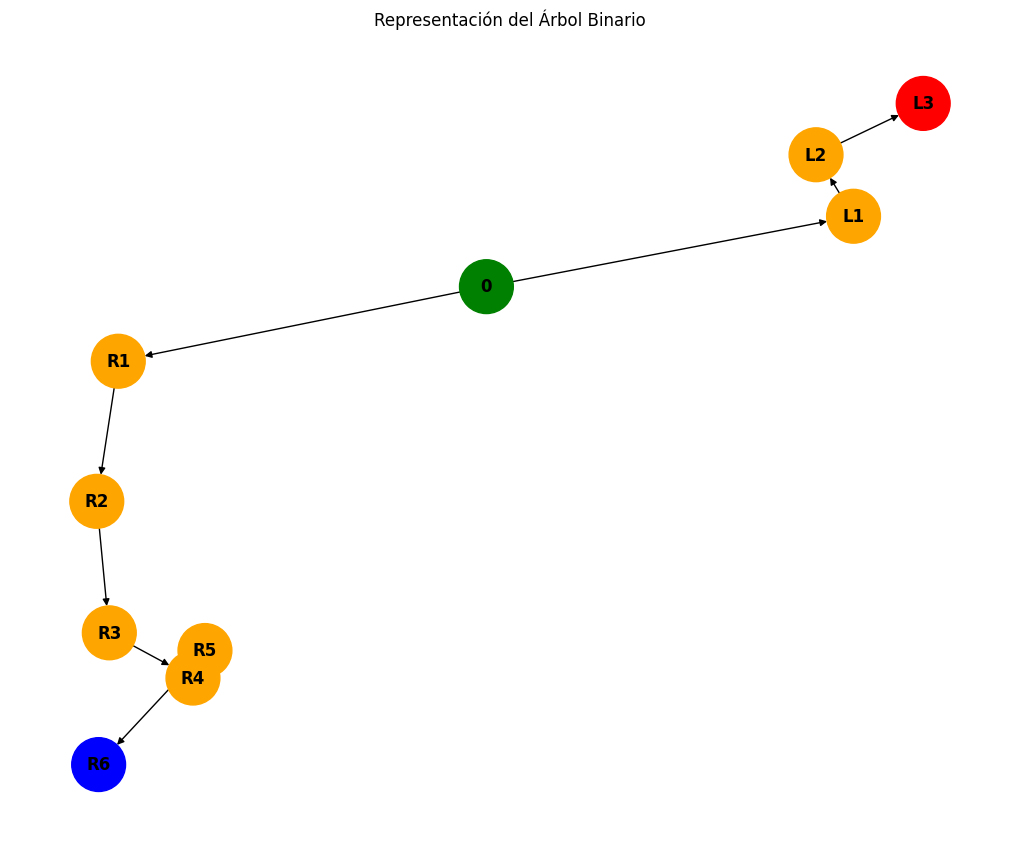

In [2]:
prof1 = 3
prof2 = 6

arbol_binario_36 = ArbolBinario(prof1,prof2)
arbol_binario_36.mostrar_grafo()

In [3]:
mcts_arbol_binario_36_1 = MCTS(arbol_binario_36.obtener_grafo())
mcts_arbol_binario_36_1.ejecutar_mcts(iteraciones=prof1 + prof2, profundidad=1)
mcts_arbol_binario_36_1.mostrar_estadisticas()


Estadísticas de los nodos:
Nodo: 0, Visitas: 9, Recompensa acumulada: 0.11764705882352941
Nodo: L1, Visitas: 5, Recompensa acumulada: 0.23529411764705882
Nodo: R1, Visitas: 4, Recompensa acumulada: 0.0
Nodo: L2, Visitas: 4, Recompensa acumulada: 0.47058823529411764
Nodo: R2, Visitas: 3, Recompensa acumulada: 0.0
Nodo: L3, Visitas: 3, Recompensa acumulada: 0.7058823529411764
Nodo: R3, Visitas: 2, Recompensa acumulada: 0.0
Nodo: R4, Visitas: 1, Recompensa acumulada: 0.0


In [4]:
mcts_arbol_binario_36_1.representar_rutas_slideshow()

In [5]:
mcts_arbol_binario_36_2 = MCTS(arbol_binario_36.obtener_grafo())
mcts_arbol_binario_36_2.ejecutar_mcts(iteraciones=max([prof1,prof2])*2-1, profundidad=1)
mcts_arbol_binario_36_2.mostrar_estadisticas()

Estadísticas de los nodos:
Nodo: 0, Visitas: 11, Recompensa acumulada: 1.0588235294117647
Nodo: L1, Visitas: 5, Recompensa acumulada: 0.23529411764705882
Nodo: R1, Visitas: 6, Recompensa acumulada: 1.8823529411764706
Nodo: L2, Visitas: 4, Recompensa acumulada: 0.47058823529411764
Nodo: R2, Visitas: 5, Recompensa acumulada: 3.764705882352941
Nodo: L3, Visitas: 3, Recompensa acumulada: 0.7058823529411764
Nodo: R3, Visitas: 4, Recompensa acumulada: 7.529411764705882
Nodo: R4, Visitas: 3, Recompensa acumulada: 15.058823529411764
Nodo: R5, Visitas: 2, Recompensa acumulada: 30.11764705882353
Nodo: R6, Visitas: 1, Recompensa acumulada: 30.11764705882353


In [6]:
mcts_arbol_binario_36_2.representar_rutas_slideshow()



---

MCTS_T

In [7]:
mcts_t_arbol_binario_36_1 = MCTS_T(arbol_binario_36.obtener_grafo())
mcts_t_arbol_binario_36_1.ejecutar_mcts(iteraciones=prof1 + prof2, profundidad=1)
mcts_t_arbol_binario_36_1.mostrar_estadisticas()

Estadísticas de los nodos:
Nodo: 0, Visitas: 9, Recompensa acumulada: 1.0
Nodo: L1, Visitas: 3, Recompensa acumulada: 0.11764705882352941
Nodo: R1, Visitas: 6, Recompensa acumulada: 1.8823529411764706
Nodo: L2, Visitas: 2, Recompensa acumulada: 0.23529411764705882
Nodo: R2, Visitas: 5, Recompensa acumulada: 3.764705882352941
Nodo: L3, Visitas: 1, Recompensa acumulada: 0.23529411764705882
Nodo: R3, Visitas: 4, Recompensa acumulada: 7.529411764705882
Nodo: R4, Visitas: 3, Recompensa acumulada: 15.058823529411764
Nodo: R5, Visitas: 2, Recompensa acumulada: 30.11764705882353
Nodo: R6, Visitas: 1, Recompensa acumulada: 30.11764705882353


In [8]:
mcts_t_arbol_binario_36_1.representar_rutas_slideshow()

In [9]:
mcts_t_arbol_binario_36_2 = MCTS_T(arbol_binario_36.obtener_grafo())
mcts_t_arbol_binario_36_2.ejecutar_mcts(iteraciones=max([prof1,prof2])*2-1, profundidad=1)
mcts_t_arbol_binario_36_2.mostrar_estadisticas()

Estadísticas de los nodos:
Nodo: 0, Visitas: 11, Recompensa acumulada: 1.9411764705882355
Nodo: L1, Visitas: 3, Recompensa acumulada: 0.11764705882352941
Nodo: R1, Visitas: 8, Recompensa acumulada: 3.764705882352941
Nodo: L2, Visitas: 2, Recompensa acumulada: 0.23529411764705882
Nodo: R2, Visitas: 7, Recompensa acumulada: 7.529411764705882
Nodo: L3, Visitas: 1, Recompensa acumulada: 0.23529411764705882
Nodo: R3, Visitas: 6, Recompensa acumulada: 15.058823529411764
Nodo: R4, Visitas: 5, Recompensa acumulada: 30.11764705882353
Nodo: R5, Visitas: 4, Recompensa acumulada: 60.23529411764706
Nodo: R6, Visitas: 3, Recompensa acumulada: 90.35294117647058


In [10]:
mcts_t_arbol_binario_36_2.representar_rutas_slideshow()

#### Observamos que para este ejemplo:
* El método MCTS necesita: $\max\{prof_1,prof_2\}·2-1$ iteraciones para llegar a seleccionar el nodo óptimo.
* El método MCTS_T solo necesita: $\sum_{i=1}^2prof_i$ iteraciones para llegar a seleccionar el nodo óptimo. Resultan ser las mínimas iteraciones requeridas para poder explorar cada nodo nuevo una única vez (sin repetición de rutas).

Como era de esperar, si $prof_1<prof_2$, tenemos que las iteraciones empleadas para MCTS_T son menores o igual a las empleadas para el caso MCTS.

### Ejemplo Árbol N-ario

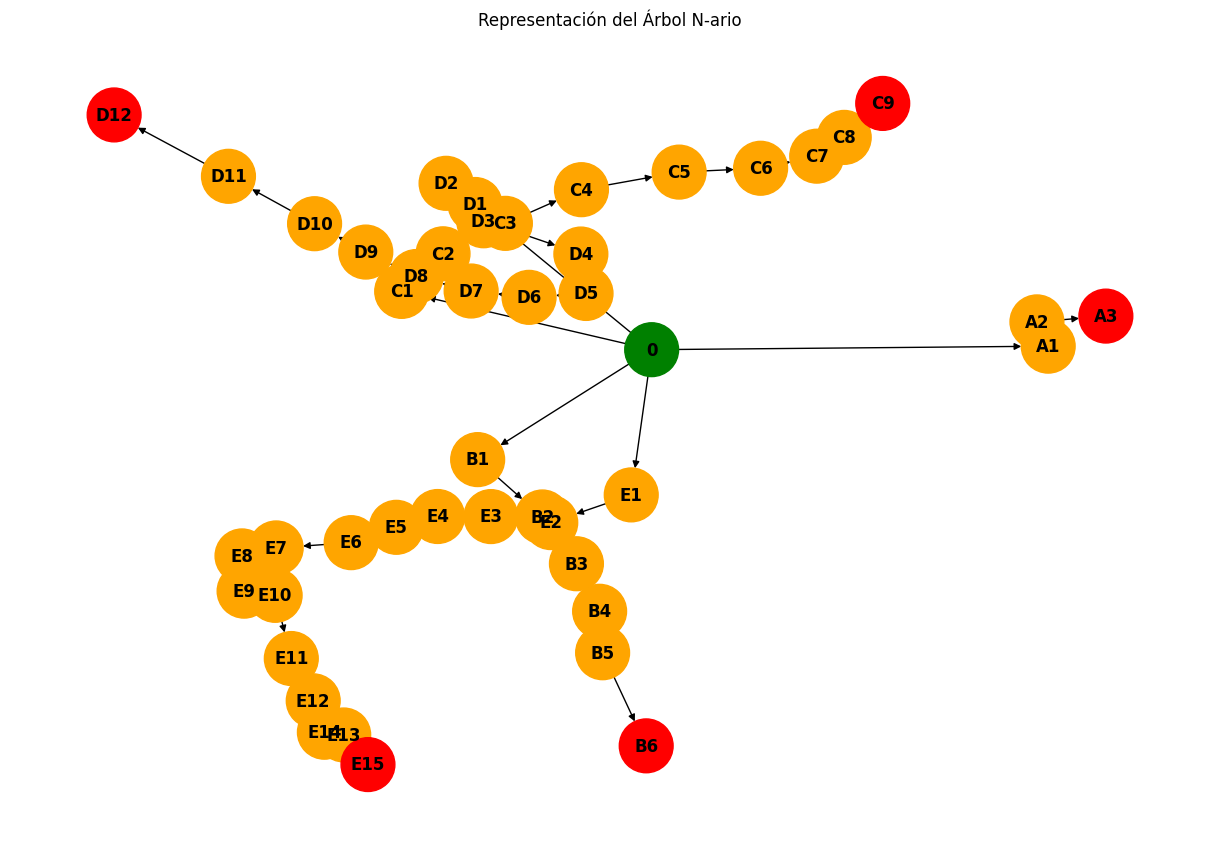

In [11]:
profundidades = [3,6,9,12,15]
arbol_Nario_3691215 = ArbolNario(profundidades)
arbol_Nario_3691215.mostrar_grafo()

sum_profundidades = sum(profundidades)
ramas_por_profundidadmaxima = len(profundidades)*(max(profundidades)-1)+1

MCTS

In [12]:
mcts_arbol_Nario_3691215_1 = MCTS(arbol_Nario_3691215.obtener_grafo())
mcts_arbol_Nario_3691215_1.ejecutar_mcts(iteraciones=sum_profundidades, profundidad=1)
mcts_arbol_Nario_3691215_1.mostrar_estadisticas()


Estadísticas de los nodos:
Nodo: 0, Visitas: 45, Recompensa acumulada: 0.01037955754936887
Nodo: A1, Visitas: 9, Recompensa acumulada: 0.000351849408453182
Nodo: B1, Visitas: 9, Recompensa acumulada: 0.0035184940845318204
Nodo: C1, Visitas: 9, Recompensa acumulada: 0.016888771605752737
Nodo: D1, Visitas: 9, Recompensa acumulada: 0.0
Nodo: E1, Visitas: 9, Recompensa acumulada: 0.0
Nodo: A2, Visitas: 8, Recompensa acumulada: 0.000703698816906364
Nodo: B2, Visitas: 8, Recompensa acumulada: 0.007036988169063641
Nodo: C2, Visitas: 8, Recompensa acumulada: 0.03377754321150547
Nodo: D2, Visitas: 8, Recompensa acumulada: 0.0
Nodo: E2, Visitas: 8, Recompensa acumulada: 0.0
Nodo: A3, Visitas: 7, Recompensa acumulada: 0.001231472929586137
Nodo: B3, Visitas: 7, Recompensa acumulada: 0.014073976338127282
Nodo: C3, Visitas: 7, Recompensa acumulada: 0.06755508642301095
Nodo: D3, Visitas: 7, Recompensa acumulada: 0.0
Nodo: E3, Visitas: 7, Recompensa acumulada: 0.0
Nodo: B4, Visitas: 6, Recompensa acum

In [13]:
mcts_arbol_Nario_3691215_1.representar_rutas_slideshow()

In [14]:
mcts_arbol_Nario_3691215_2 = MCTS(arbol_Nario_3691215.obtener_grafo())
mcts_arbol_Nario_3691215_2.ejecutar_mcts(iteraciones=ramas_por_profundidadmaxima, profundidad=1)
mcts_arbol_Nario_3691215_2.mostrar_estadisticas()


Estadísticas de los nodos:
Nodo: 0, Visitas: 71, Recompensa acumulada: 1.1142411048071426
Nodo: A1, Visitas: 14, Recompensa acumulada: 0.0005717552887364207
Nodo: B1, Visitas: 14, Recompensa acumulada: 0.007036988169063639
Nodo: C1, Visitas: 14, Recompensa acumulada: 0.05911070062013458
Nodo: D1, Visitas: 14, Recompensa acumulada: 0.3602937942560584
Nodo: E1, Visitas: 15, Recompensa acumulada: 1.801468971280292
Nodo: A2, Visitas: 13, Recompensa acumulada: 0.0011435105774728414
Nodo: B2, Visitas: 13, Recompensa acumulada: 0.014073976338127278
Nodo: C2, Visitas: 13, Recompensa acumulada: 0.11822140124026916
Nodo: D2, Visitas: 13, Recompensa acumulada: 0.7205875885121168
Nodo: E2, Visitas: 14, Recompensa acumulada: 3.602937942560584
Nodo: A3, Visitas: 12, Recompensa acumulada: 0.0021110964507190916
Nodo: B3, Visitas: 12, Recompensa acumulada: 0.028147952676254556
Nodo: C3, Visitas: 12, Recompensa acumulada: 0.2364428024805383
Nodo: D3, Visitas: 12, Recompensa acumulada: 1.4411751770242336

In [15]:
mcts_arbol_Nario_3691215_2.representar_rutas_slideshow()



---



MCTS_T

In [16]:
mcts_t_arbol_Nario_3691215_1 = MCTS_T(arbol_Nario_3691215.obtener_grafo())
mcts_t_arbol_Nario_3691215_1.ejecutar_mcts(iteraciones=sum_profundidades, profundidad=1)
mcts_t_arbol_Nario_3691215_1.mostrar_estadisticas()

Estadísticas de los nodos:
Nodo: 0, Visitas: 45, Recompensa acumulada: 1.0
Nodo: A1, Visitas: 3, Recompensa acumulada: 8.796235211329551e-05
Nodo: B1, Visitas: 6, Recompensa acumulada: 0.0014073976338127281
Nodo: C1, Visitas: 9, Recompensa acumulada: 0.016888771605752737
Nodo: D1, Visitas: 12, Recompensa acumulada: 0.1801468971280292
Nodo: E1, Visitas: 15, Recompensa acumulada: 1.801468971280292
Nodo: A2, Visitas: 2, Recompensa acumulada: 0.00017592470422659101
Nodo: B2, Visitas: 5, Recompensa acumulada: 0.0028147952676254562
Nodo: C2, Visitas: 8, Recompensa acumulada: 0.03377754321150547
Nodo: D2, Visitas: 11, Recompensa acumulada: 0.3602937942560584
Nodo: E2, Visitas: 14, Recompensa acumulada: 3.602937942560584
Nodo: A3, Visitas: 1, Recompensa acumulada: 0.00017592470422659101
Nodo: B3, Visitas: 4, Recompensa acumulada: 0.0056295905352509125
Nodo: C3, Visitas: 7, Recompensa acumulada: 0.06755508642301095
Nodo: D3, Visitas: 10, Recompensa acumulada: 0.7205875885121168
Nodo: E3, Visita

In [17]:
mcts_t_arbol_Nario_3691215_1.representar_rutas_slideshow()

In [18]:
mcts_t_arbol_Nario_3691215_2 = MCTS_T(arbol_Nario_3691215.obtener_grafo())
mcts_t_arbol_Nario_3691215_2.ejecutar_mcts(iteraciones=ramas_por_profundidadmaxima, profundidad=1)
mcts_t_arbol_Nario_3691215_2.mostrar_estadisticas()

Estadísticas de los nodos:
Nodo: 0, Visitas: 71, Recompensa acumulada: 12.709548313321903
Nodo: A1, Visitas: 3, Recompensa acumulada: 8.796235211329551e-05
Nodo: B1, Visitas: 6, Recompensa acumulada: 0.0014073976338127281
Nodo: C1, Visitas: 9, Recompensa acumulada: 0.016888771605752737
Nodo: D1, Visitas: 12, Recompensa acumulada: 0.1801468971280292
Nodo: E1, Visitas: 41, Recompensa acumulada: 25.2205655979241
Nodo: A2, Visitas: 2, Recompensa acumulada: 0.00017592470422659101
Nodo: B2, Visitas: 5, Recompensa acumulada: 0.0028147952676254562
Nodo: C2, Visitas: 8, Recompensa acumulada: 0.03377754321150547
Nodo: D2, Visitas: 11, Recompensa acumulada: 0.3602937942560584
Nodo: E2, Visitas: 40, Recompensa acumulada: 50.4411311958482
Nodo: A3, Visitas: 1, Recompensa acumulada: 0.00017592470422659101
Nodo: B3, Visitas: 4, Recompensa acumulada: 0.0056295905352509125
Nodo: C3, Visitas: 7, Recompensa acumulada: 0.06755508642301095
Nodo: D3, Visitas: 10, Recompensa acumulada: 0.7205875885121168
Nod

In [19]:
mcts_t_arbol_Nario_3691215_2.representar_rutas_slideshow()

#### Observamos que para este ejemplo:
* El método MCTS necesita: $|\text{ramas}|·(\max(\text{profundidades})-1)+1$ iteraciones para llegar a seleccionar el nodo óptimo.
* El método MCTS_T solo necesita nuevamente $\sum_{i=1}^nprof_i$ iteraciones para llegar a seleccionar el nodo óptimo.

Luego iteraciones MCTS $\geq$ iteraciones MCTS_T.

### Ejemplo Árbol binario con Hijos

MCTS

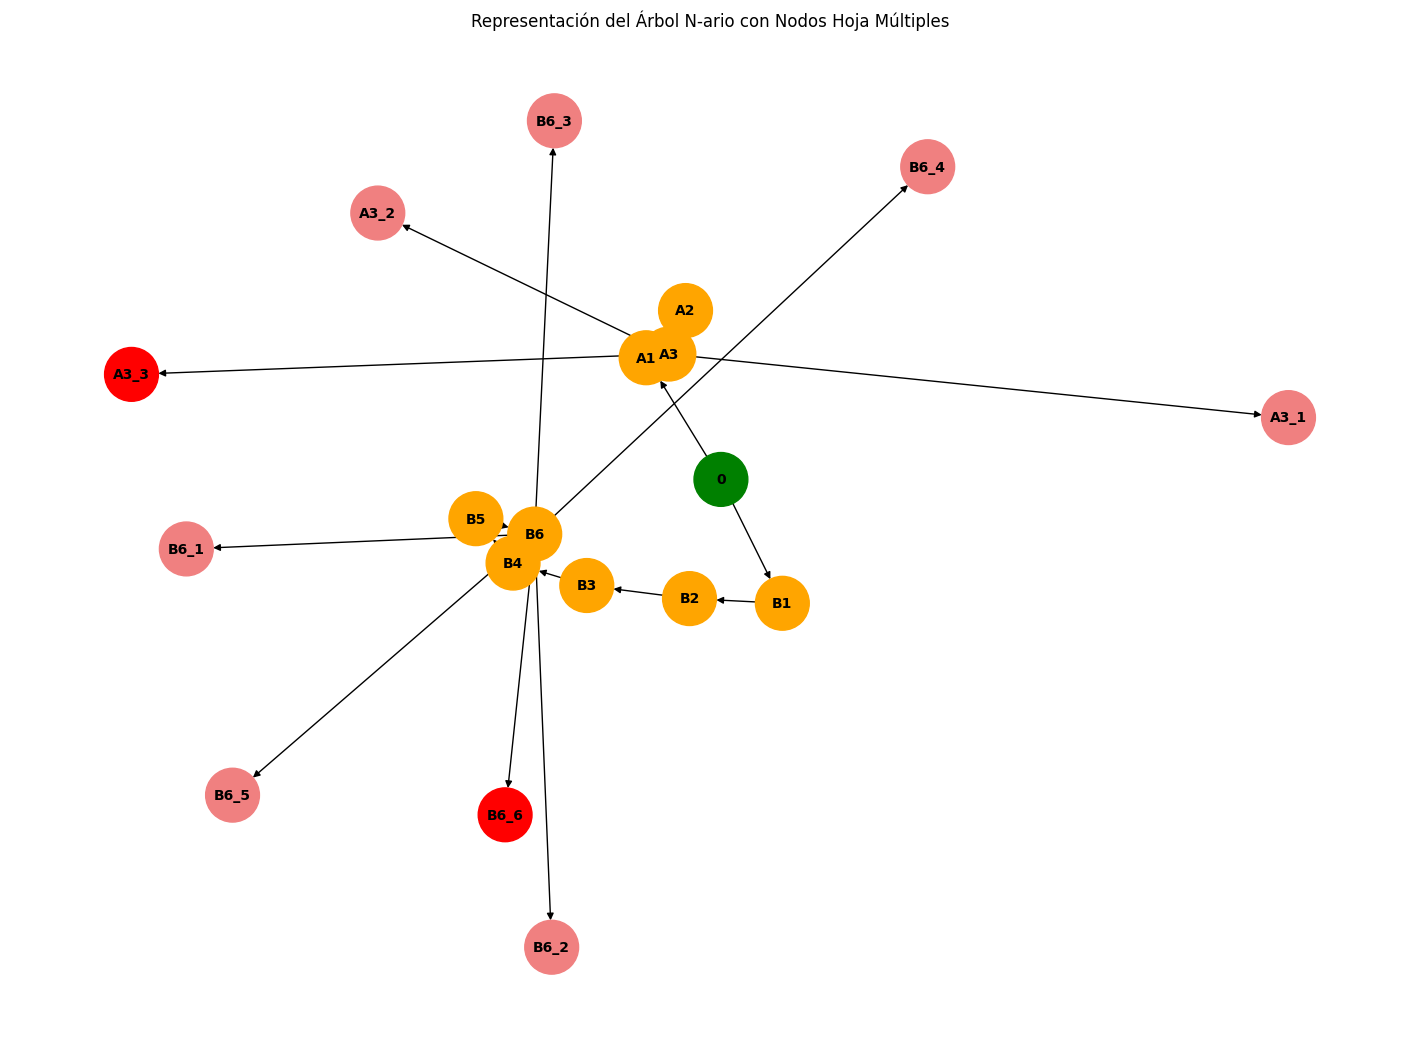

In [46]:
profundidades = [3,6]
arbol_NarioHijos_36 = ArbolNarioHijos(profundidades)
arbol_NarioHijos_36.mostrar_grafo()

sum_dobleprofundidades = sum(profundidades * 2)
sum_dobleprofundidadesmaxima = len(profundidades)*max(profundidades) * 2 


MCTS

In [47]:
mcts_arbol_NarioHijos_36_1 = MCTS(arbol_NarioHijos_36.obtener_grafo())
mcts_arbol_NarioHijos_36_1.ejecutar_mcts(iteraciones=sum_dobleprofundidades, profundidad=1)
mcts_arbol_NarioHijos_36_1.mostrar_estadisticas()


Estadísticas de los nodos:
Nodo: 0, Visitas: 18, Recompensa acumulada: 0.2647058823529412
Nodo: A1, Visitas: 9, Recompensa acumulada: 0.058823529411764705
Nodo: B1, Visitas: 9, Recompensa acumulada: 0.47058823529411764
Nodo: A2, Visitas: 8, Recompensa acumulada: 0.11764705882352941
Nodo: B2, Visitas: 8, Recompensa acumulada: 0.9411764705882353
Nodo: A3, Visitas: 7, Recompensa acumulada: 0.23529411764705882
Nodo: B3, Visitas: 7, Recompensa acumulada: 1.8823529411764706
Nodo: A3_1, Visitas: 2, Recompensa acumulada: 0.0
Nodo: A3_2, Visitas: 2, Recompensa acumulada: 0.0
Nodo: A3_3, Visitas: 2, Recompensa acumulada: 0.47058823529411764
Nodo: B4, Visitas: 6, Recompensa acumulada: 3.764705882352941
Nodo: B5, Visitas: 5, Recompensa acumulada: 7.529411764705882
Nodo: B6, Visitas: 4, Recompensa acumulada: 15.058823529411764
Nodo: B6_1, Visitas: 1, Recompensa acumulada: 0.0
Nodo: B6_2, Visitas: 1, Recompensa acumulada: 0.0
Nodo: B6_3, Visitas: 1, Recompensa acumulada: 0.0
Nodo: B6_4, Visitas: 0, 

In [48]:
mcts_arbol_NarioHijos_36_1.representar_rutas_slideshow()

In [49]:
mcts_arbol_NarioHijos_36_2 = MCTS(arbol_NarioHijos_36.obtener_grafo())
mcts_arbol_NarioHijos_36_2.ejecutar_mcts(iteraciones=sum_dobleprofundidadesmaxima, profundidad=1)
mcts_arbol_NarioHijos_36_2.mostrar_estadisticas()



Estadísticas de los nodos:
Nodo: 0, Visitas: 24, Recompensa acumulada: 0.27941176470588236
Nodo: A1, Visitas: 12, Recompensa acumulada: 0.08823529411764705
Nodo: B1, Visitas: 12, Recompensa acumulada: 0.47058823529411764
Nodo: A2, Visitas: 11, Recompensa acumulada: 0.1764705882352941
Nodo: B2, Visitas: 11, Recompensa acumulada: 0.9411764705882353
Nodo: A3, Visitas: 10, Recompensa acumulada: 0.3529411764705882
Nodo: B3, Visitas: 10, Recompensa acumulada: 1.8823529411764706
Nodo: A3_1, Visitas: 3, Recompensa acumulada: 0.0
Nodo: A3_2, Visitas: 3, Recompensa acumulada: 0.0
Nodo: A3_3, Visitas: 3, Recompensa acumulada: 0.7058823529411764
Nodo: B4, Visitas: 9, Recompensa acumulada: 3.764705882352941
Nodo: B5, Visitas: 8, Recompensa acumulada: 7.529411764705882
Nodo: B6, Visitas: 7, Recompensa acumulada: 15.058823529411764
Nodo: B6_1, Visitas: 1, Recompensa acumulada: 0.0
Nodo: B6_2, Visitas: 1, Recompensa acumulada: 0.0
Nodo: B6_3, Visitas: 1, Recompensa acumulada: 0.0
Nodo: B6_4, Visitas: 

In [50]:
mcts_arbol_NarioHijos_36_2.representar_rutas_slideshow()



---



MCTS_T

In [25]:
mcts_t_arbol_NarioHijos_36_1 = MCTS_T(arbol_NarioHijos_36.obtener_grafo())
mcts_t_arbol_NarioHijos_36_1.ejecutar_mcts(iteraciones=sum_dobleprofundidades, profundidad=1)
mcts_t_arbol_NarioHijos_36_1.mostrar_estadisticas()

Estadísticas de los nodos:
Nodo: 0, Visitas: 18, Recompensa acumulada: 0.5
Nodo: A1, Visitas: 6, Recompensa acumulada: 0.058823529411764705
Nodo: B1, Visitas: 12, Recompensa acumulada: 0.9411764705882353
Nodo: A2, Visitas: 5, Recompensa acumulada: 0.11764705882352941
Nodo: B2, Visitas: 11, Recompensa acumulada: 1.8823529411764706
Nodo: A3, Visitas: 4, Recompensa acumulada: 0.23529411764705882
Nodo: B3, Visitas: 10, Recompensa acumulada: 3.764705882352941
Nodo: A3_1, Visitas: 1, Recompensa acumulada: 0.0
Nodo: A3_2, Visitas: 1, Recompensa acumulada: 0.0
Nodo: A3_3, Visitas: 1, Recompensa acumulada: 0.23529411764705882
Nodo: B4, Visitas: 9, Recompensa acumulada: 7.529411764705882
Nodo: B5, Visitas: 8, Recompensa acumulada: 15.058823529411764
Nodo: B6, Visitas: 7, Recompensa acumulada: 30.11764705882353
Nodo: B6_1, Visitas: 1, Recompensa acumulada: 0.0
Nodo: B6_2, Visitas: 1, Recompensa acumulada: 0.0
Nodo: B6_3, Visitas: 1, Recompensa acumulada: 0.0
Nodo: B6_4, Visitas: 1, Recompensa acu

In [26]:
mcts_t_arbol_NarioHijos_36_1.representar_rutas_slideshow()

In [27]:
mcts_t_arbol_NarioHijos_36_2 = MCTS_T(arbol_NarioHijos_36.obtener_grafo())
mcts_t_arbol_NarioHijos_36_2.ejecutar_mcts(iteraciones=sum_dobleprofundidadesmaxima, profundidad=1)
mcts_t_arbol_NarioHijos_36_2.mostrar_estadisticas()

Estadísticas de los nodos:
Nodo: 0, Visitas: 24, Recompensa acumulada: 1.661764705882353
Nodo: A1, Visitas: 6, Recompensa acumulada: 0.029411764705882353
Nodo: B1, Visitas: 18, Recompensa acumulada: 3.294117647058824
Nodo: A2, Visitas: 5, Recompensa acumulada: 0.058823529411764705
Nodo: B2, Visitas: 17, Recompensa acumulada: 6.588235294117648
Nodo: A3, Visitas: 4, Recompensa acumulada: 0.11764705882352941
Nodo: B3, Visitas: 16, Recompensa acumulada: 13.176470588235295
Nodo: A3_1, Visitas: 1, Recompensa acumulada: 0.0
Nodo: A3_2, Visitas: 1, Recompensa acumulada: 0.0
Nodo: A3_3, Visitas: 1, Recompensa acumulada: 0.23529411764705882
Nodo: B4, Visitas: 15, Recompensa acumulada: 26.35294117647059
Nodo: B5, Visitas: 14, Recompensa acumulada: 52.70588235294118
Nodo: B6, Visitas: 13, Recompensa acumulada: 105.41176470588236
Nodo: B6_1, Visitas: 1, Recompensa acumulada: 0.0
Nodo: B6_2, Visitas: 1, Recompensa acumulada: 0.0
Nodo: B6_3, Visitas: 1, Recompensa acumulada: 0.0
Nodo: B6_4, Visitas: 

In [28]:
mcts_t_arbol_NarioHijos_36_2.representar_rutas_slideshow()

#### Observamos que para este ejemplo:
* El método MCTS necesita: $|\text{ramas}|·\max(\text{profundidades})·2$ iteraciones para llegar a seleccionar el nodo óptimo.
* El método MCTS_T solo necesita $\sum_{i=1}^2prof_i·2 $ iteraciones para llegar a seleccionar el nodo óptimo.

Luego iteraciones MCTS $\geq$ iteraciones MCTS_T.


### Ejemplo Árbol N-ario con Hijos

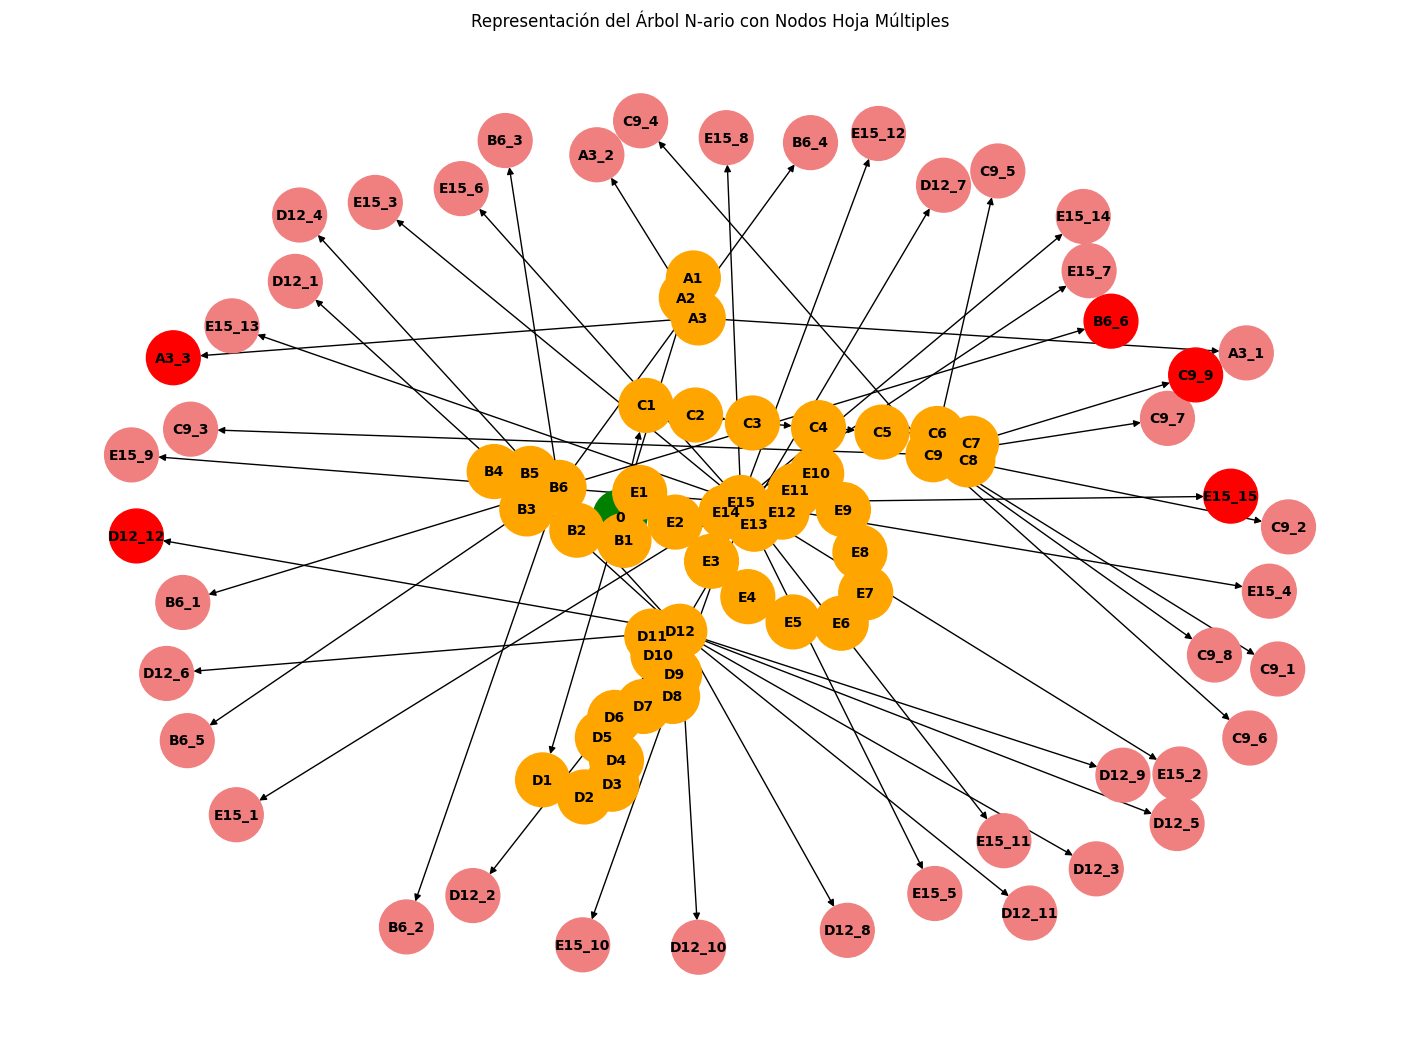

In [29]:
profundidades = [3,6,9,12,15]
arbol_NarioHijos_3691215 = ArbolNarioHijos(profundidades)
arbol_NarioHijos_3691215.mostrar_grafo()

sum_dobleprofundidades = sum(profundidades * 2)
sum_dobleprofundidadesmaxima = len(profundidades)*max(profundidades) * 2


MCTS

In [30]:
mcts_arbol_NarioHijos_3691215_1 = MCTS(arbol_NarioHijos_3691215.obtener_grafo())
mcts_arbol_NarioHijos_3691215_1.ejecutar_mcts(iteraciones=sum_dobleprofundidades, profundidad=1)
mcts_arbol_NarioHijos_3691215_1.mostrar_estadisticas()


Estadísticas de los nodos:
Nodo: 0, Visitas: 90, Recompensa acumulada: 0.22998856489422526
Nodo: A1, Visitas: 18, Recompensa acumulada: 0.00010995294014161939
Nodo: B1, Visitas: 18, Recompensa acumulada: 0.001055548225359546
Nodo: C1, Visitas: 18, Recompensa acumulada: 0.008444385802876368
Nodo: D1, Visitas: 18, Recompensa acumulada: 0.0
Nodo: E1, Visitas: 18, Recompensa acumulada: 0.450367242820073
Nodo: A2, Visitas: 17, Recompensa acumulada: 0.00021990588028323877
Nodo: B2, Visitas: 17, Recompensa acumulada: 0.002111096450719092
Nodo: C2, Visitas: 17, Recompensa acumulada: 0.016888771605752737
Nodo: D2, Visitas: 17, Recompensa acumulada: 0.0
Nodo: E2, Visitas: 17, Recompensa acumulada: 0.900734485640146
Nodo: A3, Visitas: 16, Recompensa acumulada: 0.00043981176056647755
Nodo: B3, Visitas: 16, Recompensa acumulada: 0.004222192901438184
Nodo: C3, Visitas: 16, Recompensa acumulada: 0.03377754321150547
Nodo: D3, Visitas: 16, Recompensa acumulada: 0.0
Nodo: E3, Visitas: 16, Recompensa acu

In [31]:
mcts_arbol_NarioHijos_3691215_1.representar_rutas_slideshow()

In [32]:
mcts_arbol_NarioHijos_3691215_2 = MCTS(arbol_NarioHijos_3691215.obtener_grafo())
mcts_arbol_NarioHijos_3691215_2.ejecutar_mcts(iteraciones=sum_dobleprofundidadesmaxima, profundidad=1)
mcts_arbol_NarioHijos_3691215_2.mostrar_estadisticas()



Estadísticas de los nodos:
Nodo: 0, Visitas: 150, Recompensa acumulada: 0.418799753705414
Nodo: A1, Visitas: 30, Recompensa acumulada: 0.00019791529225491485
Nodo: B1, Visitas: 30, Recompensa acumulada: 0.0014073976338127281
Nodo: C1, Visitas: 30, Recompensa acumulada: 0.025333157408629105
Nodo: D1, Visitas: 30, Recompensa acumulada: 0.36029379425605834
Nodo: E1, Visitas: 30, Recompensa acumulada: 0.450367242820073
Nodo: A2, Visitas: 29, Recompensa acumulada: 0.0003958305845098297
Nodo: B2, Visitas: 29, Recompensa acumulada: 0.0028147952676254562
Nodo: C2, Visitas: 29, Recompensa acumulada: 0.05066631481725821
Nodo: D2, Visitas: 29, Recompensa acumulada: 0.7205875885121167
Nodo: E2, Visitas: 29, Recompensa acumulada: 0.900734485640146
Nodo: A3, Visitas: 28, Recompensa acumulada: 0.0007916611690196594
Nodo: B3, Visitas: 28, Recompensa acumulada: 0.0056295905352509125
Nodo: C3, Visitas: 28, Recompensa acumulada: 0.10133262963451642
Nodo: D3, Visitas: 28, Recompensa acumulada: 1.441175177

In [33]:
mcts_arbol_NarioHijos_3691215_2.representar_rutas_slideshow()



---



MCTS_T

In [34]:
mcts_t_arbol_NarioHijos_3691215_1 = MCTS_T(arbol_NarioHijos_3691215.obtener_grafo())
mcts_t_arbol_NarioHijos_3691215_1.ejecutar_mcts(iteraciones=sum_dobleprofundidades, profundidad=1)
mcts_t_arbol_NarioHijos_3691215_1.mostrar_estadisticas()

Estadísticas de los nodos:
Nodo: 0, Visitas: 90, Recompensa acumulada: 0.25001099529401416
Nodo: A1, Visitas: 6, Recompensa acumulada: 4.3981176056647754e-05
Nodo: B1, Visitas: 12, Recompensa acumulada: 0.00035184940845318203
Nodo: C1, Visitas: 18, Recompensa acumulada: 0.004222192901438184
Nodo: D1, Visitas: 24, Recompensa acumulada: 0.0450367242820073
Nodo: E1, Visitas: 30, Recompensa acumulada: 0.450367242820073
Nodo: A2, Visitas: 5, Recompensa acumulada: 8.796235211329551e-05
Nodo: B2, Visitas: 11, Recompensa acumulada: 0.0007036988169063641
Nodo: C2, Visitas: 17, Recompensa acumulada: 0.008444385802876368
Nodo: D2, Visitas: 23, Recompensa acumulada: 0.0900734485640146
Nodo: E2, Visitas: 29, Recompensa acumulada: 0.900734485640146
Nodo: A3, Visitas: 4, Recompensa acumulada: 0.00017592470422659101
Nodo: B3, Visitas: 10, Recompensa acumulada: 0.0014073976338127281
Nodo: C3, Visitas: 16, Recompensa acumulada: 0.016888771605752737
Nodo: D3, Visitas: 22, Recompensa acumulada: 0.18014689

In [35]:
mcts_t_arbol_NarioHijos_3691215_1.representar_rutas_slideshow()

In [36]:
mcts_t_arbol_NarioHijos_3691215_2 = MCTS_T(arbol_NarioHijos_3691215.obtener_grafo())
mcts_t_arbol_NarioHijos_3691215_2.ejecutar_mcts(iteraciones=sum_dobleprofundidadesmaxima, profundidad=1)
mcts_t_arbol_NarioHijos_3691215_2.mostrar_estadisticas()

Estadísticas de los nodos:
Nodo: 0, Visitas: 150, Recompensa acumulada: 13.761193209306402
Nodo: A1, Visitas: 6, Recompensa acumulada: 2.1990588028323877e-05
Nodo: B1, Visitas: 12, Recompensa acumulada: 0.0007036988169063641
Nodo: C1, Visitas: 18, Recompensa acumulada: 0.004222192901438184
Nodo: D1, Visitas: 24, Recompensa acumulada: 0.0450367242820073
Nodo: E1, Visitas: 90, Recompensa acumulada: 27.472401812024426
Nodo: A2, Visitas: 5, Recompensa acumulada: 4.3981176056647754e-05
Nodo: B2, Visitas: 11, Recompensa acumulada: 0.0014073976338127281
Nodo: C2, Visitas: 17, Recompensa acumulada: 0.008444385802876368
Nodo: D2, Visitas: 23, Recompensa acumulada: 0.0900734485640146
Nodo: E2, Visitas: 89, Recompensa acumulada: 54.94480362404885
Nodo: A3, Visitas: 4, Recompensa acumulada: 8.796235211329551e-05
Nodo: B3, Visitas: 10, Recompensa acumulada: 0.0028147952676254562
Nodo: C3, Visitas: 16, Recompensa acumulada: 0.016888771605752737
Nodo: D3, Visitas: 22, Recompensa acumulada: 0.18014689

In [37]:
mcts_t_arbol_NarioHijos_3691215_2.representar_rutas_slideshow()

#### Observamos que para este ejemplo:
* El método MCTS necesita: $|\text{ramas}|·\max(\text{profundidades})·2$ iteraciones para llegar a seleccionar el nodo óptimo.
* El método MCTS_T tan solo necesita $\sum_{i=1}^2prof_i·2 $ iteraciones para llegar a seleccionar el nodo óptimo.

Luego iteraciones MCTS $\geq$ iteraciones MCTS_T.




---



## Comparaciones

A continuación vamos a realizar un estudio más profundo para comprobar los resultados obtenidos en los ejemplos. Para ello, vamos a comparar la ganancia media (eje vertical) con el número de iteraciones (eje horizontal) para cuatro ejemplos de árboles de distintas profundidades para los distintos ejemplos vistos anteriormente. Variando el número de iteraciones sucesivamente entre número mínimo de iteraciones necesarias para alcanzar la ruta óptima para el caso MCTS_T y MCTS para cada uno de los árboles.

#### Comparación Árbol binario

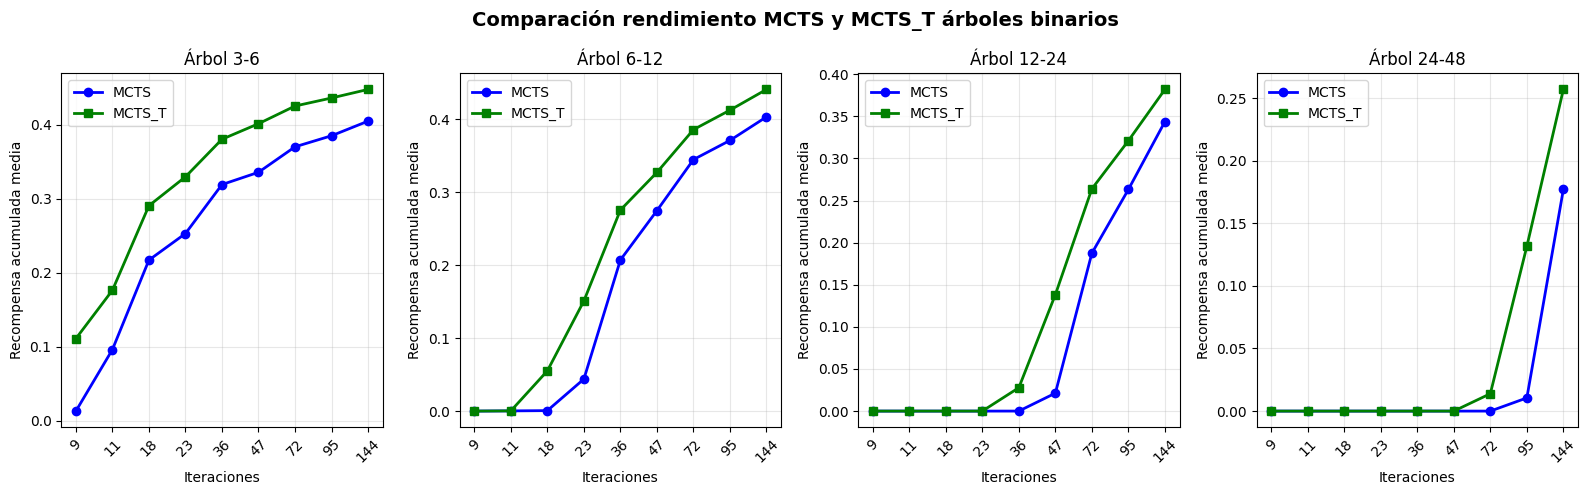

In [38]:
arbol_binario_36 = ArbolBinario(3,6)
arbol_binario_612 = ArbolBinario(6,12)
arbol_binario_1224 = ArbolBinario(12,24)
arbol_binario_2448 = ArbolBinario(24,48)

arbol_binario = [arbol_binario_36, arbol_binario_612, arbol_binario_1224, arbol_binario_2448]
nombres_arboles = ['3-6', '6-12', '12-24', '24-48']


recompensa_mcts = [[] for _ in arbol_binario]
recompensa_mcts_t = [[] for _ in arbol_binario]

iteraciones_lista = [9,11,18,23,36,47,72,95,48+48*2] #Iteraciones elegidas cuando MCTS_T encuentra optimo, MCTS encuentra optimo de manera sucesiva para cada árbol binario.

for iteracionesN in iteraciones_lista:
    for idx, arbol in enumerate(arbol_binario):

        # MCTS vanilla
        mcts_arbol = MCTS(arbol.obtener_grafo())
        mcts_arbol.ejecutar_mcts(iteraciones=iteracionesN, profundidad=1)
        # Obtener recompensa acumulada del nodo raíz
        recompensa_total_mcts = mcts_arbol.recompensas_acumuladas_nodos.get('0', 0)
        recompensa_mcts[idx].append(recompensa_total_mcts / iteracionesN)

        # MCTS_T
        mcts_t_arbol = MCTS_T(arbol.obtener_grafo())
        mcts_t_arbol.ejecutar_mcts(iteraciones=iteracionesN, profundidad=1)
        # Obtener recompensa acumulada del nodo raíz
        recompensa_total_mcts_t = mcts_t_arbol.recompensas_acumuladas_nodos.get('0', 0)
        recompensa_mcts_t[idx].append(recompensa_total_mcts_t / iteracionesN)

# Crear subplot con 4 figuras horizontales
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for idx, (ax, nombre) in enumerate(zip(axes, nombres_arboles)):
    # Eje X: índices de iteraciones
    x_values = range(len(iteraciones_lista))

    # Plotear MCTS y MCTS_T
    ax.plot(x_values, recompensa_mcts[idx], marker='o', color='blue', label='MCTS', linewidth=2)
    ax.plot(x_values, recompensa_mcts_t[idx], marker='s', color='green', label='MCTS_T', linewidth=2)

    # Configurar etiquetas
    ax.set_xlabel('Iteraciones')
    ax.set_ylabel('Recompensa acumulada media')
    ax.set_title(f'Árbol {nombre}')
    ax.set_xticks(x_values)
    ax.set_xticklabels(iteraciones_lista, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparación rendimiento MCTS y MCTS_T árboles binarios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Observamos que para el ejemplo más simple, el del árbol binario, ambas versiones del MCTS consiguen resultado muy parecidos. Siendo la versión MCTS_T la que consigue una mayor recompensa acumulada media en un menor número de iteraciones, seguida muy de cerca del la versión estandar MCTS.

### Comparación Árbol N-ario

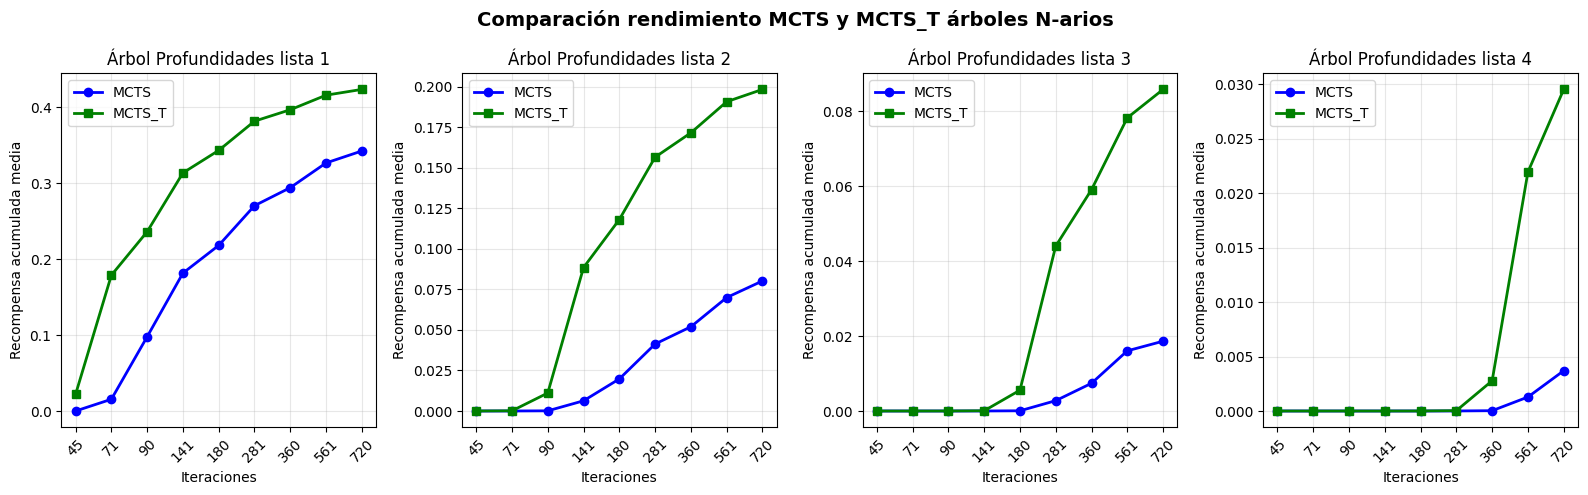

In [39]:
profundidades1 = [3,6,9,12,15]
arbol_Nario_1 = ArbolNario(profundidades1)
profundidades2 = [3,6,9,12,15] * 2
arbol_Nario_2 = ArbolNario(profundidades2)
profundidades3 = [3,6,9,12,15] * 2**2
arbol_Nario_3 = ArbolNario(profundidades3)
profundidades4 = [3,6,9,12,15] * 2**3
arbol_Nario_4 = ArbolNario(profundidades4)


arbol_Nario = [arbol_Nario_1, arbol_Nario_2, arbol_Nario_3, arbol_Nario_4]
nombres_arboles = ['Profundidades lista 1', 'Profundidades lista 2', 'Profundidades lista 3', 'Profundidades lista 4']


recompensa_mcts = [[] for _ in arbol_Nario]
recompensa_mcts_t = [[] for _ in arbol_Nario]

iteraciones_lista = [sum(profundidades1),(max(profundidades1)-1)*len(profundidades1)+1,sum(profundidades2),(max(profundidades2)-1)*len(profundidades2)+1,sum(profundidades3),(max(profundidades3)-1)*len(profundidades3)+1,sum(profundidades4),(max(profundidades4)-1)*len(profundidades4)+1,sum(profundidades4*2)] #Iteraciones elegidas cuando MCTS_T encuentra optimo, MCTS encuentra optimo de manera sucesiva para cada árbol binario.

for iteracionesN in iteraciones_lista:
    for idx, arbol in enumerate(arbol_Nario):

        # MCTS vanilla
        mcts_arbol = MCTS(arbol.obtener_grafo())
        mcts_arbol.ejecutar_mcts(iteraciones=iteracionesN, profundidad=1)
        # Obtener recompensa acumulada del nodo raíz
        recompensa_total_mcts = mcts_arbol.recompensas_acumuladas_nodos.get('0', 0)
        recompensa_mcts[idx].append(recompensa_total_mcts /iteracionesN)

        # MCTS_T
        mcts_t_arbol = MCTS_T(arbol.obtener_grafo())
        mcts_t_arbol.ejecutar_mcts(iteraciones=iteracionesN, profundidad=1)
        # Obtener recompensa acumulada del nodo raíz
        recompensa_total_mcts_t = mcts_t_arbol.recompensas_acumuladas_nodos.get('0', 0)
        recompensa_mcts_t[idx].append(recompensa_total_mcts_t / iteracionesN)

# Crear subplot con 4 figuras horizontales
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for idx, (ax, nombre) in enumerate(zip(axes, nombres_arboles)):
    # Eje X: índices de iteraciones
    x_values = range(len(iteraciones_lista))

    # Plotear MCTS y MCTS_T
    ax.plot(x_values, recompensa_mcts[idx], marker='o', color='blue', label='MCTS', linewidth=2)
    ax.plot(x_values, recompensa_mcts_t[idx], marker='s', color='green', label='MCTS_T', linewidth=2)

    # Configurar etiquetas
    ax.set_xlabel('Iteraciones')
    ax.set_ylabel('Recompensa acumulada media')
    ax.set_title(f'Árbol {nombre}')
    ax.set_xticks(x_values)
    ax.set_xticklabels(iteraciones_lista, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparación rendimiento MCTS y MCTS_T árboles N-arios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Observamos que al añadirle mayor ramificación al ejemplo anterior, ambas versiones del MCTS consiguen resultados más distintivos. Siendo la versión MCTS_T la que consigue una mayor recompensa acumulada media en un menor número de iteraciones, seguida de cerca por la versión estándar MCTS para el caso de la lista 1 de profundidades (la más simple) y esta diferencia comienza a notarse más a medida que los valores de profundidades de la lista aumentan.

### Comparación Árbol binario con Hijos

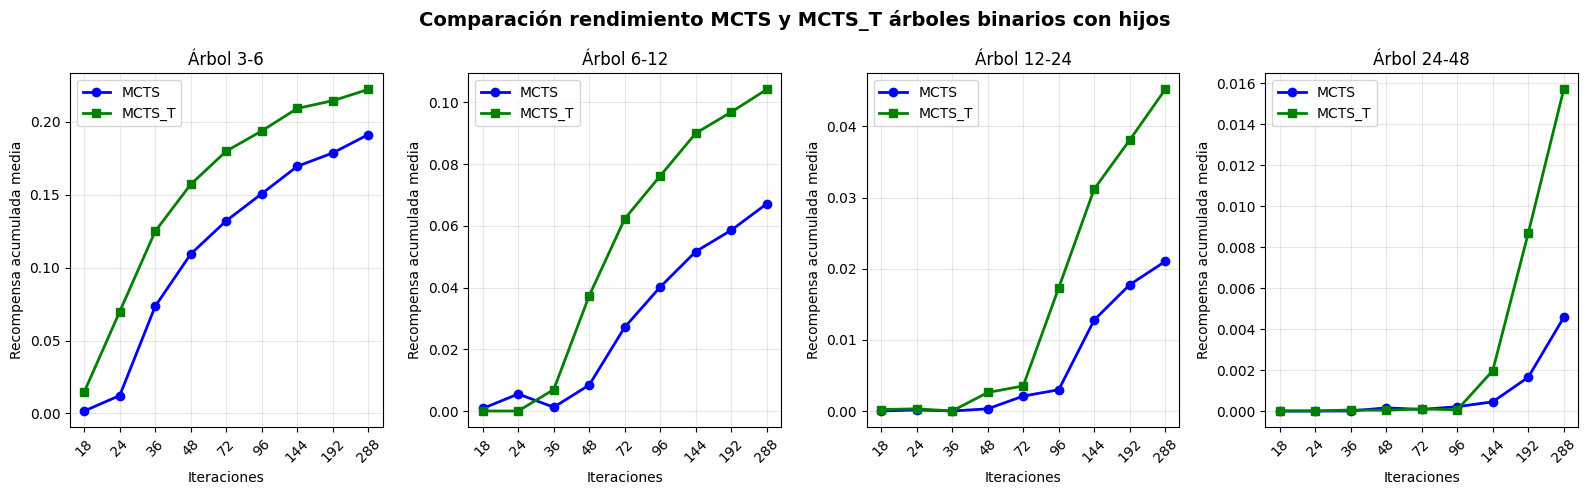

In [40]:
profundidades1 = [3,6]
arbol_binario_hijos_36 = ArbolNarioHijos(profundidades1)
profundidades2 = [3,6] * 2
arbol_binario_hijos_612 = ArbolNarioHijos(profundidades2)
profundidades3 = [3,6] * 2**2
arbol_binario_hijos_1224 = ArbolNarioHijos(profundidades3)
profundidades4 = [3,6] * 2**3
arbol_binario_hijos_2448 = ArbolNarioHijos(profundidades4)

arbol_binario_hijos = [arbol_binario_hijos_36, arbol_binario_hijos_612, arbol_binario_hijos_1224, arbol_binario_hijos_2448]
nombres_arboles = ['3-6', '6-12', '12-24', '24-48']


recompensa_mcts = [[] for _ in arbol_binario_hijos]
recompensa_mcts_t = [[] for _ in arbol_binario_hijos]

iteraciones_lista = [sum(profundidades1 * 2),len(profundidades1)*max(profundidades1) * 2,sum(profundidades2 * 2),len(profundidades2)*max(profundidades2) * 2,sum(profundidades3 * 2),len(profundidades3)*max(profundidades3) * 2,sum(profundidades4 * 2),len(profundidades4)*max(profundidades4) * 2,sum((profundidades4 * 2) *2)] #Iteraciones elegidas cuando MCTS_T encuentra optimo, MCTS encuentra optimo de manera sucesiva para cada árbol binario.

for iteracionesN in iteraciones_lista:
    for idx, arbol in enumerate(arbol_binario_hijos):

        # MCTS vanilla
        mcts_arbol = MCTS(arbol.obtener_grafo())
        mcts_arbol.ejecutar_mcts(iteraciones=iteracionesN, profundidad=1)
        # Obtener recompensa acumulada del nodo raíz
        recompensa_total_mcts = mcts_arbol.recompensas_acumuladas_nodos.get('0', 0)
        recompensa_mcts[idx].append(recompensa_total_mcts / iteracionesN)

        # MCTS_T
        mcts_t_arbol = MCTS_T(arbol.obtener_grafo())
        mcts_t_arbol.ejecutar_mcts(iteraciones=iteracionesN, profundidad=1)
        # Obtener recompensa acumulada del nodo raíz
        recompensa_total_mcts_t = mcts_t_arbol.recompensas_acumuladas_nodos.get('0', 0)
        recompensa_mcts_t[idx].append(recompensa_total_mcts_t / iteracionesN)

# Crear subplot con 4 figuras horizontales
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for idx, (ax, nombre) in enumerate(zip(axes, nombres_arboles)):
    # Eje X: índices de iteraciones
    x_values = range(len(iteraciones_lista))

    # Plotear MCTS y MCTS_T
    ax.plot(x_values, recompensa_mcts[idx], marker='o', color='blue', label='MCTS', linewidth=2)
    ax.plot(x_values, recompensa_mcts_t[idx], marker='s', color='green', label='MCTS_T', linewidth=2)

    # Configurar etiquetas
    ax.set_xlabel('Iteraciones')
    ax.set_ylabel('Recompensa acumulada media')
    ax.set_title(f'Árbol {nombre}')
    ax.set_xticks(x_values)
    ax.set_xticklabels(iteraciones_lista, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparación rendimiento MCTS y MCTS_T árboles binarios con hijos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Observamos que para el ejemplo del árbol binario con hijos, se obtienen diferencias mayores respecto a los métodos respecto del caso simple del árbol binario. Siendo la versión MCTS_T la que consigue una mayor recompensa acumulada media, por lo general, en un menor número de iteraciones, seguida de cerca por la versión estándar MCTS para el caso de la lista 1 de profundidades (la más simple) y nuevamente esta diferencia comienza a notarse más a medida que los valores de profundidades de la lista aumentan.

### Comparación Árbol N-ario con Hijos

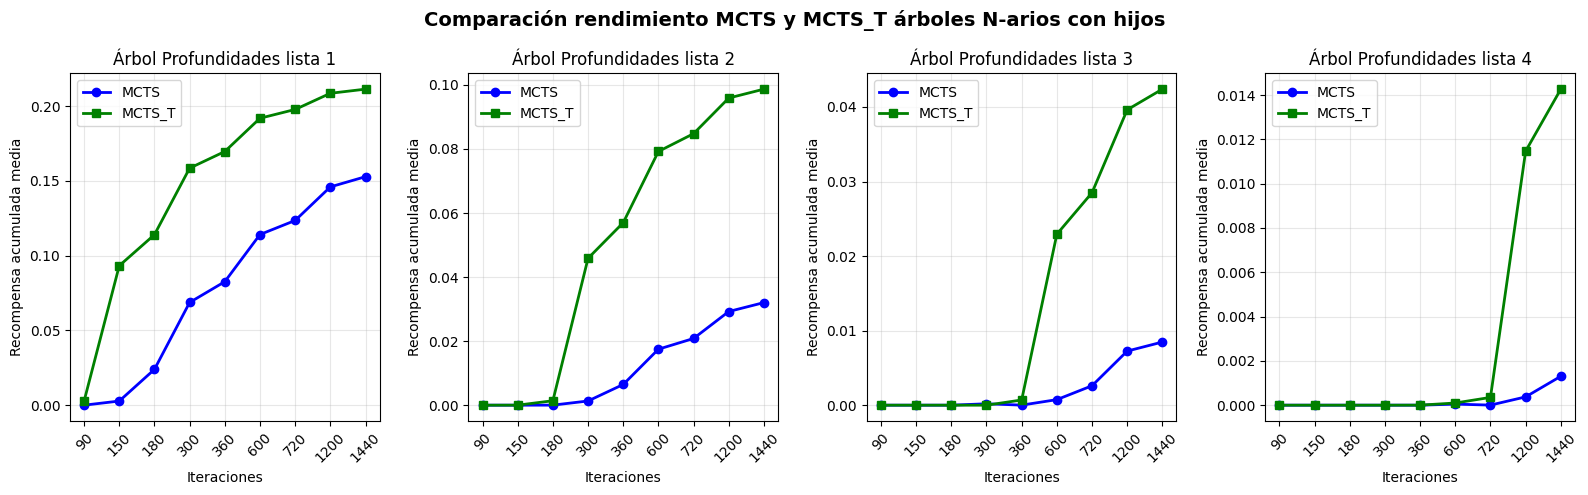

In [41]:
profundidades1 = [3,6,9,12,15]
arbol_Nario_hijos_1 = ArbolNarioHijos(profundidades1)
profundidades2 = [3,6,9,12,15] * 2
arbol_Nario_hijos_2 = ArbolNarioHijos(profundidades2)
profundidades3 = [3,6,9,12,15] * 2**2
arbol_Nario_hijos_3 = ArbolNarioHijos(profundidades3)
profundidades4 = [3,6,9,12,15] * 2**3
arbol_Nario_hijos_4 = ArbolNarioHijos(profundidades4)

arbol_Nario_hijos = [arbol_Nario_hijos_1, arbol_Nario_hijos_2, arbol_Nario_hijos_3, arbol_Nario_hijos_4]
nombres_arboles = ['Profundidades lista 1', 'Profundidades lista 2', 'Profundidades lista 3', 'Profundidades lista 4']


recompensa_mcts = [[] for _ in arbol_Nario_hijos]
recompensa_mcts_t = [[] for _ in arbol_Nario_hijos]

iteraciones_lista = [sum(profundidades1 * 2),len(profundidades1)*max(profundidades1) * 2,sum(profundidades2 * 2),len(profundidades2)*max(profundidades2) * 2,sum(profundidades3 * 2),len(profundidades3)*max(profundidades3) * 2,sum(profundidades4 * 2),len(profundidades4)*max(profundidades4) * 2,sum((profundidades4 * 2) *2)] #Iteraciones elegidas cuando MCTS_T encuentra optimo, MCTS encuentra optimo de manera sucesiva para cada árbol binario.

for iteracionesN in iteraciones_lista:
    for idx, arbol in enumerate(arbol_Nario_hijos):

        # MCTS vanilla
        mcts_arbol = MCTS(arbol.obtener_grafo())
        mcts_arbol.ejecutar_mcts(iteraciones=iteracionesN, profundidad=1)
        # Obtener recompensa acumulada del nodo raíz
        recompensa_total_mcts = mcts_arbol.recompensas_acumuladas_nodos.get('0', 0)
        recompensa_mcts[idx].append(recompensa_total_mcts / iteracionesN)

        # MCTS_T
        mcts_t_arbol = MCTS_T(arbol.obtener_grafo())
        mcts_t_arbol.ejecutar_mcts(iteraciones=iteracionesN, profundidad=1)
        # Obtener recompensa acumulada del nodo raíz
        recompensa_total_mcts_t = mcts_t_arbol.recompensas_acumuladas_nodos.get('0', 0)
        recompensa_mcts_t[idx].append(recompensa_total_mcts_t / iteracionesN)

# Crear subplot con 4 figuras horizontales
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for idx, (ax, nombre) in enumerate(zip(axes, nombres_arboles)):
    # Eje X: índices de iteraciones
    x_values = range(len(iteraciones_lista))

    # Plotear MCTS y MCTS_T
    ax.plot(x_values, recompensa_mcts[idx], marker='o', color='blue', label='MCTS', linewidth=2)
    ax.plot(x_values, recompensa_mcts_t[idx], marker='s', color='green', label='MCTS_T', linewidth=2)

    # Configurar etiquetas
    ax.set_xlabel('Iteraciones')
    ax.set_ylabel('Recompensa acumulada media')
    ax.set_title(f'Árbol {nombre}')
    ax.set_xticks(x_values)
    ax.set_xticklabels(iteraciones_lista, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparación rendimiento MCTS y MCTS_T árboles N-arios con hijos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Observamos que para el último ejemplo del árbol N-ario con hijos, se obtienen diferencias parecidas a las obtenidas en ejemplo del árbol N-ario, aunque con un rendimiento aparentemente peor para caso MCTS. Siendo la versión MCTS_T la que consigue una mayor recompensa acumulada media en un menor número de iteraciones, seguida de la versión estandar MCTS para el caso de la lista 1 de profundidades (la más simple) y cada vez más distante para valores de profundidades mayores.



---



## CONCLUSIONES

* Aunque los resultados obtenidos en la comparación hagan parecer que el método MCTS_T resulta ser mejor encontrando la ruta óptima respecto de la versión estándar MCTS. Hay que tener en cuenta que los ejemplos (diseñados mediante una lluvia de ideas con ChatGPT) que hemos considerado han sido construidos para beneficiar la exploración en los nodos más profundos. Esto sigue con el principio de que un mayor esfuerzo otorga una mayor recompensa, pero para grafos que esto no se cumpliera, el factor de profundidad podría hacer que empleasemos demasiadas iteraciones a explorar ramas muy profundas con posibles recompensas despreciables.

* Para estos ejemplos asimétricos, observamos que cuanta mayor asimetría tenga el grafo, mejores resultados obtiene la versión MCTS_T respecto a MCTS. Lo cual indica que puede llegar a ser beneficioso utilizar la variable de profundidad cuando tratemos de resolver grafos de este tipo.

* Aunque para el número inicial de iteraciones se obtengan resultados prometedores para el caso MCTS_T. Cabe destacar, ambos métodos obtendrían resultados similares a partir de cierta iteración.

* Respecto a estas iteraciones iniciales. La importancia recae en que, si continuásemos con la implementación del método de manera que nuestro criterio de selección del nodo a elegir sea aquel que tenga un mayor número de veces seleccionada (y no mayor recompensa acumulada), nos interesa que el método comience a seleccionar cuanto antes la ruta óptima para no correr el riesgo de seleccionar al final un nodo subóptimo por haber sido seleccionado más veces para un número limitado de iteraciones.

* Una desventaja a considerar del caso MCTS_T es que requiere un mayor costo de memoria/computo al tener que acumular/calcular la variable de profundidad. Para los ejemplos propuestos en este trabajo no ha supuesto ningún inconveniente, pero para una implementación de grafos de mucho mayor tamaño habría que tenerlo en cuenta.


***Trabajo para la asignatura Síntesis, Verificación y Razonamiento de Agentes Inteligentes
del Máster Universitario en Lógica, Computación e Inteligencia Artificial (MULCIA) de Sevilla. Curso 2025/26***

***Realizado por Manuel Enciso Martínez***